# YP2021 — Báo cáo khoa học dữ liệu: dự đoán tình trạng việc làm sau tốt nghiệp

*Thanh niên Hàn Quốc giai đoạn đầu chuyển tiếp ra thị trường lao động — Youth Panel 2021 (KEIS)*

---

## Tóm tắt

Báo cáo này trình bày trọn vẹn vòng đời phân tích dữ liệu trên bộ **Youth Panel 2021
(YP2021)** của Viện Phát triển Nhân lực Hàn Quốc (KEIS), với câu hỏi trọng tâm: *những
đặc trưng nào của một người vừa hoàn tất giáo dục sau trung học có liên hệ với khả năng
người đó **có việc làm ở wave 4** (`employed_w04`)?* Toàn bộ phân tích bám lấy một mẫu
pilot gồm **5.687 respondent** đã tốt nghiệp, được trích ra từ khung panel 12.213 người
theo dõi qua bốn đợt khảo sát.

Mạch báo cáo đi theo đúng thứ tự của một dự án khoa học dữ liệu hoàn chỉnh. Trước hết,
chúng tôi xác lập **phạm vi và bộ ba Quần thể – Khung chọn mẫu – Mẫu (P-A-S)** cùng các
rủi ro chệch, rồi **định lượng sai số lấy mẫu** bằng mô phỏng urn/binomial, bootstrap và
biến thiên qua nhiều lần chia dữ liệu. Tiếp đó là **tiền xử lý và trích xuất đặc trưng**
từ dữ liệu thô, phần **khám phá & trực quan hóa (EDA)** cả cơ bản lẫn chuyên sâu (khung
Bernoulli/Binomial, nhận diện phân phối, ứng viên biến đổi), và **phân tích liên hệ
feature × target** có kiểm soát overclaim. Sau khi lập **catalog đặc trưng + kiểm toán
sẵn sàng + checklist chống rò rỉ**, chúng tôi **xây dựng và đánh giá mô hình phân loại
nâng cao** — baseline, hồi quy logistic L1/L2, Random Forest — kèm ROC/PR/calibration/
threshold/subgroup và **cầu nối toán học** từ log-odds tới cross-entropy và gradient
descent. Cuối cùng là kết luận và **phụ lục tái lập**.

Một nguyên tắc xuyên suốt cần nêu ngay từ đầu: mọi kết luận trong báo cáo đều mang tính
**liên quan / dự đoán**, không phải nhân quả; mọi con số đều **quan sát được trực tiếp
từ dữ liệu** đã qua pipeline, và bộ YP2021 **không được gộp chung** với GOMS hay KEEP II
vì khác thiết kế khảo sát và không có định danh chung.

> **Lưu ý tái lập.** Các ô code dưới đây gọi trực tiếp những module đã có unit-test trong
> `src/` (dataset, evaluate, sampling_variation, deep_eda, feature_catalog). Nhờ đó con
> số và hình trong báo cáo **trùng khớp** với artefact ở `reports/`, và mọi mô phỏng đều
> seed cố định `RANDOM_STATE = 42`.


## Mục lục

1. [Thiết lập môi trường và nguồn dữ liệu](#1.-Thiết-lập-môi-trường-và-nguồn-dữ-liệu)
2. [Phạm vi dự án và bộ ba P-A-S](#2.-Phạm-vi-dự-án-và-bộ-ba-Quần-thể-–-Khung-chọn-mẫu-–-Mẫu) — funnel, attrition, ba loại mẫu, chệch & sai số
3. [Sai số lấy mẫu và bất định](#3.-Sai-số-lấy-mẫu-và-bất-định-(urn/binomial-·-bootstrap-·-split-variation)) — urn/binomial · bootstrap · split variation
4. [Tiền xử lý và trích xuất đặc trưng từ raw](#4.-Tiền-xử-lý-và-trích-xuất-đặc-trưng-từ-dữ-liệu-thô) — clean/impute/groupby/melt/cut/regex/encode
5. [Khám phá dữ liệu và trực quan hóa](#5.-Khám-phá-dữ-liệu-và-trực-quan-hóa) — phân phối, mô-men, coverage
6. [EDA chuyên sâu](#6.-EDA-chuyên-sâu:-khung-Bernoulli/Binomial,-phân-phối-lý-thuyết,-biến-đổi) — Bernoulli/Binomial, phân phối lý thuyết, transformation
7. [Mối liên hệ giữa đặc trưng và outcome](#7.-Mối-liên-hệ-giữa-đặc-trưng-và-outcome) — tương quan, kiểm định, subgroup ranking, đa biến
8. [Catalog đặc trưng, readiness audit, leakage checklist](#8.-Catalog-đặc-trưng,-kiểm-toán-sẵn-sàng-và-checklist-chống-rò-rỉ)
9. [Mô hình hóa và đánh giá nâng cao](#9.-Mô-hình-hóa,-đánh-giá-nâng-cao-và-đánh-đổi-bias–variance) — kiểm tra modeling-ready, baseline/LogReg/RF, ROC/PR/calibration/threshold, subgroup fairness, cầu nối toán học
10. [Kết luận](#10.-Kết-luận)
11. [Phụ lục — Tái lập](#11.-Phụ-lục-—-Tái-lập-(reproducibility-checklist))

> **Quy ước đọc.** Mỗi phần mở đầu bằng đoạn thuyết minh đặt vấn đề, theo sau là ô code
> sinh bảng/hình từ dữ liệu thật và đoạn diễn giải kết quả. Toàn bộ con số quan sát trực
> tiếp từ pipeline; mọi kết luận là **liên quan/dự đoán, không nhân quả**.


## 1. Thiết lập môi trường và nguồn dữ liệu

Mọi phân tích trong báo cáo đọc từ **lớp đã xử lý (processed)** và các bảng trung gian
(interim) do pipeline `src/data/youth_panel/` sinh ra, chứ không chạm trực tiếp vào file
Stata gốc — ngoại trừ phần minh hoạ wrangling ở Mục 4, nơi chúng tôi cố tình quay lại
`raw_tables` để cho thấy *quy trình* biến đổi dữ liệu. Lý do của kỷ luật này là các
**mã bỏ qua (skip codes)** của khảo sát chỉ được làm sạch ở lớp processed; đọc thẳng dữ
liệu thô mà không xử lý chúng sẽ bóp méo mọi thống kê.

Bảng dữ liệu trung tâm là `yp2021_processed_pilot_w04_en.parquet` (nhãn đã dịch sang
tiếng Anh để vẽ biểu đồ). Bên cạnh đó là bảng tóm tắt tham gia panel, bảng funnel chọn
mẫu, bảng độ phủ (coverage) và bảng đặc trưng job-history ở cấp cá nhân. Ô mã dưới đây
nạp tất cả nguồn này một lần, đăng ký bộ phông chữ hiển thị song song nhãn Hàn và dấu
tiếng Việt, rồi định nghĩa vài hàm trợ giúp dùng lại xuyên suốt báo cáo.


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Lưu lại backend hiển thị (inline) để khôi phục sau khi import các module dùng
# matplotlib.use("Agg") ở cấp module (vd src.visualization.*).
INLINE_BACKEND = matplotlib.get_backend()

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))  # cho phép import src.* khi modeling

INTERIM = PROJECT_ROOT / 'data/interim/youth_panel'
META = INTERIM / '_metadata'
PROCESSED_PATH = PROJECT_ROOT / 'data/processed/youth_panel/pilot/yp2021_processed_pilot_w04_en.parquet'
COVERAGE_PATH = PROJECT_ROOT / 'data/processed/youth_panel/pilot/yp2021_processed_coverage.parquet'
JOB_HISTORY_PATH = INTERIM / 'person_features/job_history_person_features.parquet'

def use_inline():
    """Khôi phục backend hiển thị + phông sau khi import module đặt backend Agg."""
    matplotlib.use(INLINE_BACKEND)
    plt.rcParams['font.family'] = ['Malgun Gothic', 'DejaVu Sans']
    plt.rcParams['axes.unicode_minus'] = False

sns.set_theme(style='whitegrid', palette='colorblind')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 140
# Malgun Gothic hiển thị được cả nhãn Hàn lẫn dấu tiếng Việt; tắt unicode_minus
# để dấu trừ không biến thành ô vuông.
plt.rcParams['font.family'] = ['Malgun Gothic', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_parquet(PROCESSED_PATH)
panel = pd.read_parquet(META / 'panel_participation_summary.parquet')
funnel = pd.read_parquet(META / 'analysis_sample_funnel.parquet')
coverage = pd.read_parquet(COVERAGE_PATH)
job_history = pd.read_parquet(JOB_HISTORY_PATH)

NUMERIC_FEATURES = ['age_w04', 'graduation_gpa_yp100', 'job_changes',
                    'avg_job_duration_months', 'total_jobs']
TARGET = 'employed_w04'

def show():
    plt.tight_layout()
    plt.show()

print(f'Mẫu pilot: {df.shape[0]:,} respondent × {df.shape[1]} cột')
print(f'Tỷ lệ có việc (employed_w04): {df[TARGET].mean():.1%}')

Mẫu pilot: 5,687 respondent × 47 cột
Tỷ lệ có việc (employed_w04): 75.6%


## 2. Phạm vi dự án và bộ ba Quần thể – Khung chọn mẫu – Mẫu

Trước khi đụng tới bất kỳ con số nào, một dự án khoa học dữ liệu nghiêm túc phải nói rõ
nó *đang nói về ai*. YP2021 được định vị trong ba chiều phạm vi: về **không gian** là
thanh niên Hàn Quốc; về **thời gian** là giai đoạn 2017–2024 với độ trễ panel bốn đợt
khảo sát; và về **lĩnh vực** là quá trình chuyển tiếp từ giáo dục sang việc làm.

Bộ ba P-A-S cụ thể hoá phạm vi đó thành các tập đối tượng lồng nhau. **Quần thể mục tiêu
(P)** mà dự án muốn suy luận là nhóm đã tốt nghiệp cao đẳng/đại học trở lên, đang ở giai
đoạn đầu sau tốt nghiệp. **Khung chọn mẫu (A)** là toàn bộ panel YP2021 gồm 12.213
respondent được KEIS theo dõi qua wave 1–4 cùng bảng lịch sử việc làm. **Mẫu phân tích
(S)** là tập pilot wave 4 sau khi áp quy tắc `w04 == 1 and w04edu >= 3`. Điểm mấu chốt
là khung A *rộng hơn* quần thể P: panel gốc tuyển cả thanh niên 19–28 tuổi nói chung,
bao gồm người chưa đạt ngưỡng cao đẳng/đại học, nên ta buộc phải **lọc theo học vấn** để
thu khung A về đúng P. Chính bước lọc này tạo ra selection funnel mà ô mã dưới đây dựng
lại từ số liệu quan sát được.

| Thành phần | YP2021 cụ thể hoá |
|---|---|
| **P — Quần thể mục tiêu** | Người tốt nghiệp CĐ/ĐH trở lên, giai đoạn sau tốt nghiệp |
| **Quần thể nguồn/thiết kế** | Thanh niên Hàn Quốc 19–28 tuổi tại wave 1 (panel KEIS) — *rộng hơn* P |
| **A — Khung chọn mẫu** | Panel YP2021: 12.213 respondent theo dõi qua wave 1–4 + job-history |
| **S — Mẫu phân tích** | Pilot wave 4 sau lọc học vấn: `w04 == 1 and w04edu >= 3` (5.687) |


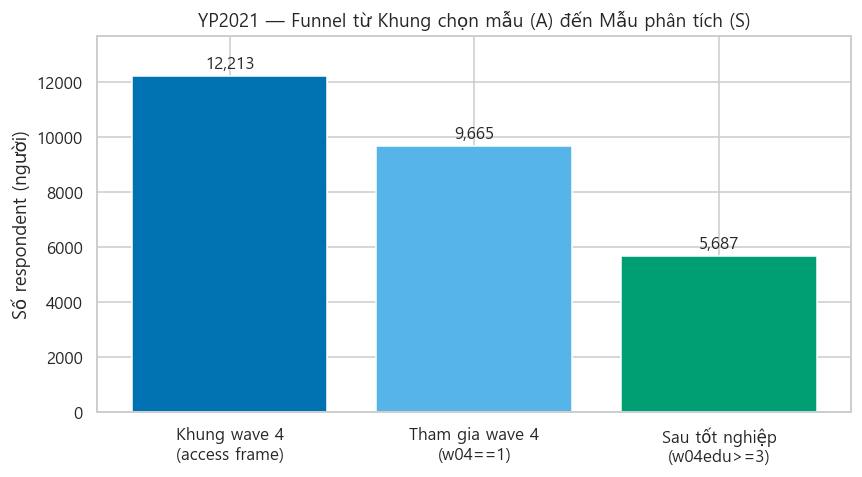

In [2]:
# Selection funnel: từ khung A (toàn bộ wave 4) thu hẹp dần về mẫu phân tích S.
core = funnel[funnel['step_order'] <= 3].copy()
labels = ['Khung wave 4\n(access frame)', 'Tham gia wave 4\n(w04==1)', 'Sau tốt nghiệp\n(w04edu>=3)']
counts = core['respondent_count'].tolist()
frame_n = int(funnel.loc[funnel['funnel_step'] == 'w04_frame', 'respondent_count'].iloc[0])

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(labels, counts, color=['#0072B2', '#56B4E9', '#009E73'])
for bar, c in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, c + 120, f'{c:,}', ha='center', va='bottom', fontsize=11)
ax.set_ylabel('Số respondent (người)')
ax.set_title('YP2021 — Funnel từ Khung chọn mẫu (A) đến Mẫu phân tích (S)')
ax.set_ylim(0, frame_n * 1.12)
show()

Vì YP2021 là dữ liệu **panel**, hiện tượng không phản hồi không biểu hiện thành từ
chối lẻ tẻ mà thành **rơi rụng (attrition)** tích luỹ qua các đợt: một bộ phận người trả
lời ở wave đầu không còn xuất hiện ở wave sau. Đường tham gia dưới đây cho thấy quy mô
attrition quan sát được, và đây là rủi ro chệch quan trọng nhất phải ghi nhớ khi diễn
giải bất kỳ kết quả nào — người rời panel có thể khác biệt một cách hệ thống so với
người ở lại.


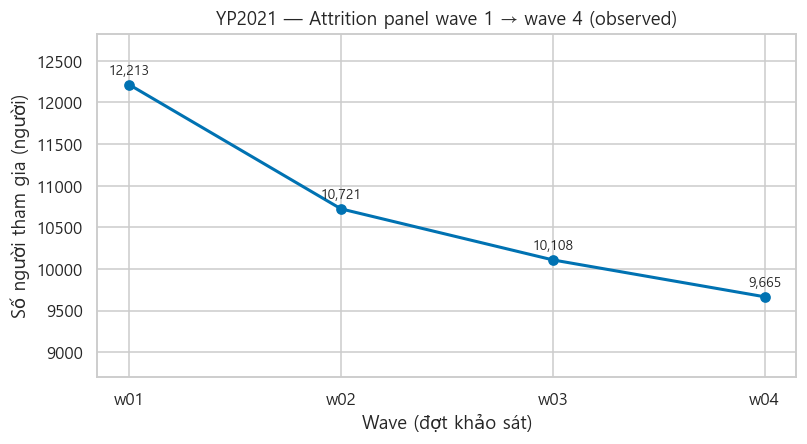

Giữ chân wave 1 → wave 4: 79.1% (9,665/12,213)


In [3]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(panel['wave'], panel['participated'], marker='o', color='#0072B2', linewidth=2)
for _, r in panel.iterrows():
    ax.text(r['wave'], r['participated'] + 120, f"{int(r['participated']):,}", ha='center', fontsize=9)
ax.set_ylabel('Số người tham gia (người)')
ax.set_xlabel('Wave (đợt khảo sát)')
ax.set_title('YP2021 — Attrition panel wave 1 → wave 4 (observed)')
ax.set_ylim(panel['participated'].min() * 0.9, panel['participated'].max() * 1.05)
show()

retention = panel['participated'].iloc[-1] / panel['participated'].iloc[0]
print(f"Giữ chân wave 1 → wave 4: {retention:.1%} "
      f"({panel['participated'].iloc[-1]:,}/{panel['participated'].iloc[0]:,})")

Đối chiếu với checklist rủi ro của đồ án, năm loại chệch và sai số đều có biểu hiện
cụ thể trong YP2021. **Chệch bao phủ** đến từ việc khung A là thanh niên nói chung, rộng
hơn quần thể graduate, buộc phải lọc học vấn. **Chệch lựa chọn** lộ ra ở chỗ nhóm có dữ
liệu ngành/GPA chi tiết chỉ chiếm khoảng 17% mẫu và có tỷ lệ có việc khác hẳn phần còn
lại — một tiểu mẫu chọn lọc, không thể dùng ngây thơ làm đặc trưng cho toàn mẫu. **Chệch
không phản hồi** chính là attrition vừa nêu. **Chệch đo lường** nằm ở chỗ job-history
dựa trên hồi tưởng và GPA là biến phân loại được chuẩn hoá riêng cho YP. Về phương sai,
**sai số lấy mẫu** được lượng hoá ngay ở Mục 3 tiếp theo; trong khi **sai số phân bổ
(assignment)** *không áp dụng* vì YP2021 là khảo sát quan sát, không có phân nhóm thử
nghiệm ngẫu nhiên.


### 2.1. Ba loại mẫu: chính, nhạy cảm và rà soát

Một quyết định thiết kế quan trọng — học theo cách KEEP II tách `analysis_sample` —
là YP2021 **không dùng một mẫu duy nhất** cho mọi mục đích, mà phân vai ba loại mẫu để
cô lập rủi ro chọn lọc:

| Loại mẫu | Định nghĩa | Vai trò |
|---|---|---|
| **Mẫu chính (main)** | 5.687 người, đặc trưng phủ đầy đủ (nhân khẩu, học vấn, gia đình) | Mọi kết luận & mô hình **lõi** dựa trên mẫu này |
| **Mẫu nhạy cảm (sensitivity)** | Tập con ~17% có khối học vấn chi tiết (ngành/GPA/loại trường) | Chỉ dùng cho mô hình `--narrow-scope` kèm cờ chỉ báo khuyết — *kiểm tra*, không phải kết luận chính |
| **Mẫu rà soát (review)** | Nhóm có liên kết job-history (4.932) / có thời lượng việc (1.717) | Dùng mô tả outcome phụ; **không** dùng làm feature/target chính vì thiên lệch lựa chọn |

Lý do tách bạch: tiểu mẫu có khối học vấn chi tiết thuộc mô-đun "vừa tốt nghiệp đợt này"
và có tỷ lệ có việc khác hẳn toàn mẫu (≈51,8% so với 75,6%). Trộn nó vào mẫu chính một
cách ngây thơ sẽ tiêm **chệch lựa chọn** vào mọi ước lượng. Vì vậy khối biến này bị giữ
ngoài mô hình lõi và chỉ xuất hiện ở mô hình nhạy cảm — nơi ta chủ động gắn cờ khuyết để
đọc kết quả một cách thận trọng (xem Mục 8 và 9).


## 3. Sai số lấy mẫu và bất định (urn/binomial · bootstrap · split variation)

Mẫu phân tích chỉ là **một** lần rút từ quần thể; nếu khảo sát lại, mọi ước lượng sẽ
chệch đi đôi chút. Phần này định lượng độ "rung lắc" đó bằng ba lăng kính bổ trợ nhau,
thay vì chỉ dựa vào một khoảng tin cậy giải tích duy nhất. Toàn bộ tính toán nằm trong
module `src.models.youth_panel.sampling_variation` (đã có unit-test); ở đây ta gọi lại để
con số trùng khớp với `reports/data_check/yp2021_sampling_variation_summary.md`.

**Mô hình urn / Binomial** coi mỗi người là một phép thử Bernoulli "có/không việc" với
xác suất `p̂`; số người có việc do đó tuân theo phân phối Binomial(n, p̂). **Bootstrap**
lấy mẫu lại *có hoàn lại* từ chính mẫu pilot để dựng phân phối thực nghiệm của tỷ lệ —
và của cả ROC-AUC mô hình — mà không cần giả định phân phối. **Split variation** thì
huấn luyện lại mô hình qua nhiều lần chia train/test ngẫu nhiên để xem chất lượng có phụ
thuộc may rủi của một lần chia hay không.


In [4]:
from src.models.youth_panel.dataset import build_modeling_data, load_processed_pilot
from src.models.youth_panel import sampling_variation as sv

# Module mặc định N_BOOTSTRAP=2000, N_URN=5000, N_SPLITS=200 (như artefact production).
# Giảm nhẹ để notebook chạy nhanh nhưng kết luận không đổi; bỏ 3 dòng dưới để dùng số đầy đủ.
sv.N_BOOTSTRAP = 1000
sv.N_URN_SIMULATIONS = 4000
sv.N_SPLITS = 80

samp_data = build_modeling_data(load_processed_pilot(), include_narrow_scope=False)
samp = sv.run_sampling_variation(samp_data)
display(samp.summary_frame.round(4))

,experiment,estimate,se_or_std,ci_low,ci_high,method,n_draws
0,employment_rate_analytic,0.7565,0.0057,0.7453,0.7676,normal_approx,NaN
1,employment_rate_urn_binomial,0.7563,0.0057,0.7452,0.7674,binomial_simulation,4000.0
2,employment_rate_bootstrap,0.7563,0.0055,0.7459,0.7670,bootstrap_resample,1000.0
3,test_roc_auc_bootstrap,0.6799,0.0181,0.6439,0.7129,bootstrap_test_set,1000.0
4,test_roc_auc_split_variation,0.6811,0.0161,0.6487,0.7182,random_8020_splits,80.0
5,test_accuracy_split_variation,0.7577,0.0041,0.7504,0.7654,random_8020_splits,80.0


Bảng trên cho thấy điều cốt lõi: **ba cách ước lượng tỷ lệ có việc gần như trùng
nhau** (CI 95% ≈ ±1,1 điểm phần trăm). Đây đúng là điều lý thuyết kỳ vọng khi cỡ mẫu lớn
và `p̂` không sát 0/1 — xấp xỉ Normal, mô hình urn Binomial và bootstrap hội tụ về cùng
độ rộng, qua đó **xác nhận** khoảng tin cậy giải tích là đáng tin. Biểu đồ dưới chồng
phân phối lấy mẫu mô phỏng từ urn lên đường mật độ Normal giải tích để thấy sự khớp này.


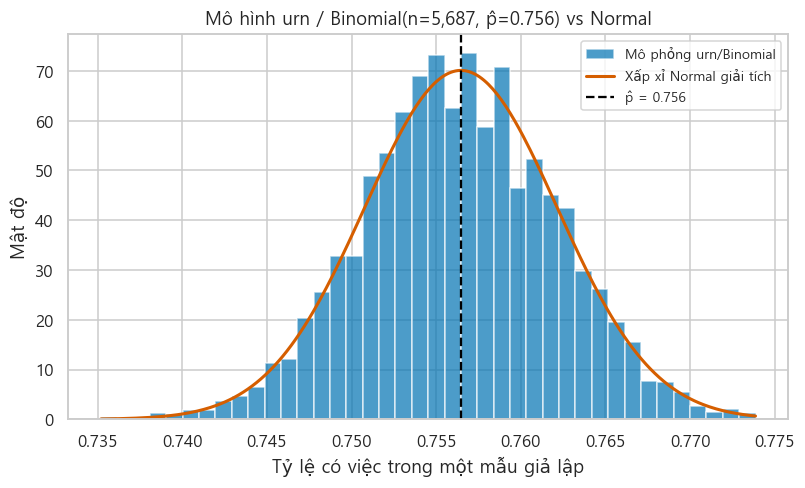

In [5]:
use_inline()
fig, ax = plt.subplots(figsize=(7.5, 4.6))
ax.hist(samp.urn_draws, bins=40, density=True, color='#0072B2', alpha=0.7, label='Mô phỏng urn/Binomial')
xs = np.linspace(samp.urn_draws.min(), samp.urn_draws.max(), 300)
pdf = (1/(samp.analytic_se*np.sqrt(2*np.pi)))*np.exp(-0.5*((xs-samp.rate_point)/samp.analytic_se)**2)
ax.plot(xs, pdf, color='#D55E00', linewidth=2, label='Xấp xỉ Normal giải tích')
ax.axvline(samp.rate_point, color='black', ls='--', label=f'p̂ = {samp.rate_point:.3f}')
ax.set_xlabel('Tỷ lệ có việc trong một mẫu giả lập')
ax.set_ylabel('Mật độ')
ax.set_title(f'Mô hình urn / Binomial(n={samp.n:,}, p̂={samp.rate_point:.3f}) vs Normal')
ax.legend(fontsize=9)
show()

Quan trọng hơn cho mục tiêu dự đoán là **độ bất định của chất lượng mô hình**.
Bootstrap trên tập kiểm thử cho khoảng tin cậy của ROC-AUC, còn split variation cho phân
phối của AUC/accuracy qua nhiều lần chia. Nếu khoảng ROC-AUC **không chứa 0.5**, ta có
bằng chứng tín hiệu phân loại là thật chứ không phải nhiễu lấy mẫu.


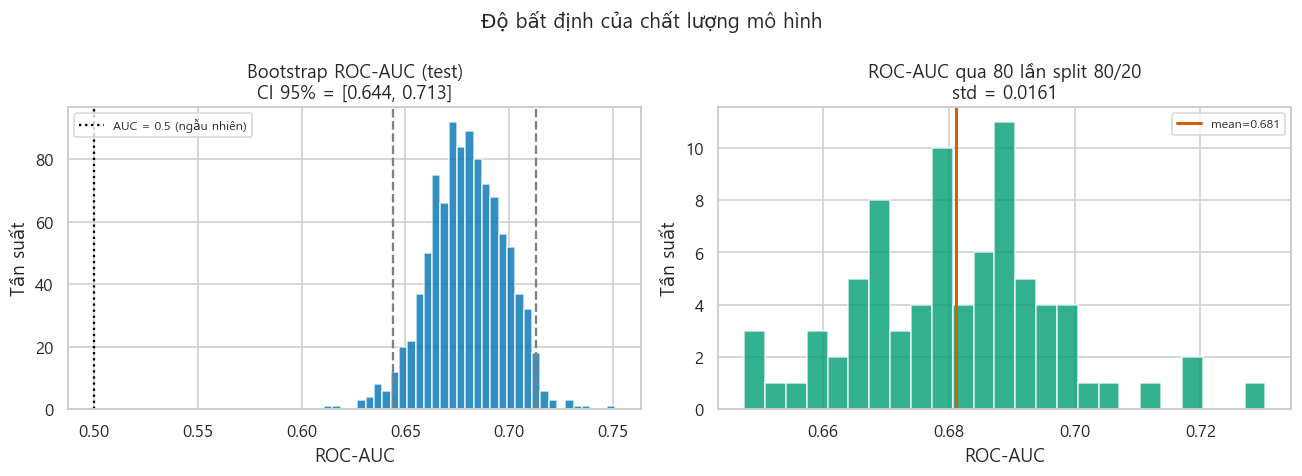

Kết luận: khoảng ROC-AUC loại trừ 0.5 ⇒ tín hiệu phân loại là THẬT (dù yếu ~0.68);
biến thiên qua split nhỏ (std≈0.016) ⇒ model ổn định, không phụ thuộc một lần chia.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
ax = axes[0]
ax.hist(samp.bootstrap_auc_draws, bins=35, color='#0072B2', alpha=0.8)
lo, hi = np.quantile(samp.bootstrap_auc_draws, [0.025, 0.975])
ax.axvline(0.5, color='black', ls=':', label='AUC = 0.5 (ngẫu nhiên)')
ax.axvline(lo, color='grey', ls='--'); ax.axvline(hi, color='grey', ls='--')
ax.set_title(f'Bootstrap ROC-AUC (test)\nCI 95% = [{lo:.3f}, {hi:.3f}]')
ax.set_xlabel('ROC-AUC'); ax.set_ylabel('Tần suất'); ax.legend(fontsize=8)

ax = axes[1]
ax.hist(samp.split_auc, bins=25, color='#009E73', alpha=0.8)
ax.axvline(samp.split_auc.mean(), color='#D55E00', lw=2, label=f'mean={samp.split_auc.mean():.3f}')
ax.set_title(f'ROC-AUC qua {sv.N_SPLITS} lần split 80/20\nstd = {samp.split_auc.std(ddof=1):.4f}')
ax.set_xlabel('ROC-AUC'); ax.set_ylabel('Tần suất'); ax.legend(fontsize=8)
fig.suptitle('Độ bất định của chất lượng mô hình', fontsize=13)
show()

print('Kết luận: khoảng ROC-AUC loại trừ 0.5 ⇒ tín hiệu phân loại là THẬT (dù yếu ~0.68);')
print(f'biến thiên qua split nhỏ (std≈{samp.split_auc.std(ddof=1):.3f}) ⇒ model ổn định, không phụ thuộc một lần chia.')

## 4. Tiền xử lý và trích xuất đặc trưng từ dữ liệu thô

Phần này quay về lớp `raw_tables` — bản materialize trực tiếp từ các file `.dta` của
Stata — để phơi bày *quy trình* biến đổi dữ liệu, thay vì chỉ trình bày kết quả đã làm
sẵn ở lớp processed. Mỗi tiểu mục tương ứng với một nhóm kỹ thuật wrangling trong yêu
cầu đồ án: làm sạch và điền khuyết, đổi độ chi tiết bằng gom nhóm, chuyển dạng rộng ↔
dài, rời rạc hóa, trích xuất bằng biểu thức chính quy, và mã hóa biến phân loại.

Bước nền tảng nhất là xử lý **mã bỏ qua**. Dữ liệu Stata gốc giữ nguyên các sentinel như
`9090908` hay `9999999` để đánh dấu câu hỏi bị bỏ qua hoặc không trả lời; nếu coi chúng
là giá trị số thật, mọi trung bình và phương sai sẽ sai lệch nghiêm trọng. Vì vậy việc
đầu tiên của mọi phân tích là biến chúng thành `NaN`, sau đó mới bàn tới chiến lược điền
khuyết.


In [7]:
RAW_TABLES = INTERIM / 'raw_tables'
W04_PATH = RAW_TABLES / 'w04' / 'yp2021_w04.parquet'
JH_RAW_PATH = RAW_TABLES / 'w01_w04' / 'yp2021_job_history_w01_w04.parquet'
SKIP_CODES = {9090908, 9090909, 9999997, 9999998, 9999999}

w04 = pd.read_parquet(W04_PATH, columns=['sampid', 'w04', 'w04edu', 'w04age', 'gender',
                                         'w04region_a', 'w04edu_f', 'w04edu_m', 'y04f308'])

def mask_skip_codes(series):
    return series.where(~series.isin(SKIP_CODES))

clean = w04.copy()
for col in ['w04edu', 'w04edu_f', 'w04edu_m', 'y04f308']:
    before = clean[col].notna().sum()
    clean[col] = mask_skip_codes(clean[col])
    print(f'{col:12s}: {before - clean[col].notna().sum():5d} giá trị skip-code → NaN')

w04edu      :     0 giá trị skip-code → NaN
w04edu_f    :     0 giá trị skip-code → NaN
w04edu_m    :     0 giá trị skip-code → NaN
y04f308     :     0 giá trị skip-code → NaN


Sau khi cô lập được phần khuyết thật, ta áp **ba chiến lược điền khuyết** tùy theo
bản chất của biến. Với học vấn cha mẹ — vốn khuyết theo logic nhánh câu hỏi chứ không
ngẫu nhiên — ta không bịa giá trị mà tạo thêm **cờ chỉ báo khuyết (missing indicator)**
để mô hình tự học. Tuổi được điền bằng **trung vị** vì bền với phân phối lệch, còn nhóm
tài sản hộ gia đình được điền bằng **trung bình** làm tròn. Cách phân biệt này quan
trọng: điền khuyết sai bản chất sẽ tiêm nhiễu hoặc giả định MCAR không có cơ sở.


In [8]:
imputed = clean.copy()
for col in ['w04edu_f', 'w04edu_m']:
    imputed[col + '_missing'] = imputed[col].isna().astype(int)
imputed['w04age'] = imputed['w04age'].fillna(imputed['w04age'].median())
imputed['y04f308'] = imputed['y04f308'].fillna(round(imputed['y04f308'].mean()))

print('Khuyết còn lại sau điền:')
print(imputed[['w04age', 'y04f308', 'w04edu_f', 'w04edu_m']].isna().sum().to_string())
print('\nCờ chỉ báo khuyết đã tạo:', [c for c in imputed.columns if c.endswith('_missing')])

Khuyết còn lại sau điền:
w04age         0
y04f308        0
w04edu_f    3036
w04edu_m    2739

Cờ chỉ báo khuyết đã tạo: ['w04edu_f_missing', 'w04edu_m_missing']


Bảng `job_history` có **độ chi tiết theo từng đợt việc làm (job-spell)**: một người
có thể ứng với nhiều dòng. Để đưa về cấp **cá nhân**, ta `groupby('sampid')` rồi tổng
hợp — một phép **đổi độ chi tiết (granularity)** kinh điển, biến dữ liệu nhiều-dòng-một-
người thành một-dòng-một-người với các đặc trưng phái sinh như số đợt việc và khoảng năm
hoạt động.


In [9]:
jh = pd.read_parquet(JH_RAW_PATH, columns=['sampid', 'jobnum', 'JOB1', 'JOB2'])
jh = jh.rename(columns={'JOB1': 'start_year', 'JOB2': 'start_month'})
print('Độ chi tiết job-spell:', jh.shape, '| số người duy nhất:', jh['sampid'].nunique())

person_level = (jh.groupby('sampid')
                  .agg(n_job_spells=('sampid', 'size'),
                       first_start_year=('start_year', 'min'),
                       last_start_year=('start_year', 'max'))
                  .reset_index())
person_level['years_active'] = person_level['last_start_year'] - person_level['first_start_year']
print('Độ chi tiết cấp cá nhân:', person_level.shape)
display(person_level.head())

Độ chi tiết job-spell: (27127, 4) | số người duy nhất: 9083
Độ chi tiết cấp cá nhân: (9083, 5)


,sampid,n_job_spells,first_start_year,last_start_year,years_active
0,100001,1,2024.0,2024.0,0.0
1,100003,1,2022.0,2022.0,0.0
2,100004,5,2021.0,2023.0,2.0
3,100006,1,2022.0,2022.0,0.0
4,100010,4,2020.0,2020.0,0.0


Thông tin tham gia panel tự nhiên ở **dạng rộng** — mỗi wave một cột. Để vẽ
attrition hay gom nhóm thuận tiện, ta dùng `melt()` đưa về **dạng dài/tidy**, nơi mỗi
dòng là một cặp respondent–wave. Khi đã ở dạng dài, việc đếm số người tham gia mỗi wave
chỉ còn là một dòng `groupby`.


In [10]:
waves = {}
for w in ['w01', 'w02', 'w03', 'w04']:
    path = RAW_TABLES / w / f'yp2021_{w}.parquet'
    waves[w] = pd.read_parquet(path, columns=['sampid', w]).set_index('sampid')[w]
wide = pd.DataFrame(waves).reset_index()
wide.columns = ['sampid', 'wave1', 'wave2', 'wave3', 'wave4']
print('Dạng RỘNG (mỗi wave một cột):', wide.shape)
display(wide.head(3))

long = wide.melt(id_vars='sampid', var_name='wave', value_name='participation_flag')
long['participated'] = (long['participation_flag'] == 1).astype(int)
print('Dạng DÀI (mỗi dòng = một respondent-wave):', long.shape)
display(long.groupby('wave')['participated'].sum().to_frame('participated'))

Dạng RỘNG (mỗi wave một cột): (12213, 5)


,sampid,wave1,wave2,wave3,wave4
0,100001,1,1,1,1
1,100002,1,1,1,1
2,100003,1,1,1,1


Dạng DÀI (mỗi dòng = một respondent-wave): (48852, 4)


,participated
wave,
wave1,12213
wave2,10721
wave3,10108
wave4,9665


Hai kỹ thuật còn lại làm việc với biến liên tục và biến văn bản. **Rời rạc hóa**
chia tuổi liên tục thành các nhóm thứ bậc bằng `pd.cut`, với ranh giới chọn theo phân
phối quan sát ở EDA. **Biểu thức chính quy** thì được minh hoạ trên một trường ngày dạng
chuỗi `"YYYY-MM"` dựng từ năm/tháng số: ta dùng lớp ký tự `\d`, các điểm neo `^` `$`,
ký hiệu định lượng `{4}` `{1,2}`, nhóm `( )` và toán tử lựa chọn `|` để vừa trích xuất
vừa kiểm định tính hợp lệ của trường.


In [11]:
# Rời rạc hóa tuổi bằng pd.cut.
imputed['age_band'] = pd.cut(imputed['w04age'], bins=[21, 24, 27, 30, 100],
                             labels=['22-24', '25-27', '28-30', '31+'])
print('Phân bố nhóm tuổi:')
print(imputed['age_band'].value_counts().sort_index().to_string())

# Dựng trường ngày dạng văn bản rồi parse lại bằng regex.
spell = jh.dropna(subset=['start_year', 'start_month']).copy()
spell['start_date_text'] = (spell['start_year'].astype(int).astype(str) + '-'
                            + spell['start_month'].astype(int).astype(str).str.zfill(2))

extracted = spell['start_date_text'].str.extract(r'^(\d{4})-(\d{1,2})$')
extracted.columns = ['year_re', 'month_re']
valid_month = spell['start_date_text'].str.contains(r'-(0?[1-9]|1[0-2])$', regex=True)
contaminated = spell['start_date_text'].str.contains(r'[^\d\-]', regex=True)
print('\nVí dụ chuỗi ngày & kết quả trích xuất regex:')
display(pd.concat([spell['start_date_text'], extracted], axis=1).head(5))
print('Dòng có tháng hợp lệ cú pháp:', int(valid_month.sum()), '/', len(spell))
print('Dòng chứa ký tự lạ (không phải số/gạch):', int(contaminated.sum()))

Phân bố nhóm tuổi:
age_band
22-24    4002
25-27    3897
28-30    3293
31+      1021

Ví dụ chuỗi ngày & kết quả trích xuất regex:


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_27680\121837314.py:14: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  valid_month = spell['start_date_text'].str.contains(r'-(0?[1-9]|1[0-2])$', regex=True)


,start_date_text,year_re,month_re
0,2024-05,2024,05
1,2022-07,2022,07
2,2021-11,2021,11
3,2021-11,2021,11
4,2021-11,2021,11


Dòng có tháng hợp lệ cú pháp: 27126 / 27126
Dòng chứa ký tự lạ (không phải số/gạch): 0


Cuối cùng, **mã hóa** biến đổi các cột định danh thành biến số để mô hình toán học
tiếp nhận được. `pd.get_dummies` cho **one-hot** đầy đủ, còn tham số `drop_first=True`
cho **dummy** bỏ bớt một mức mỗi biến nhằm tránh đa cộng tuyến. Hai cách cho số cột khác
nhau, và lựa chọn giữa chúng tùy thuộc mô hình hạ nguồn có hệ số chặn hay không.


In [12]:
encode_src = imputed[['sampid', 'gender', 'w04region_a', 'w04edu']].copy()
encode_src['gender'] = encode_src['gender'].map({1: 'Male', 2: 'Female'})
one_hot = pd.get_dummies(encode_src, columns=['gender', 'w04region_a'], prefix=['sex', 'region'])
dummy = pd.get_dummies(encode_src, columns=['gender', 'w04region_a'], prefix=['sex', 'region'], drop_first=True)
print('Số cột one-hot :', one_hot.shape[1])
print('Số cột dummy   :', dummy.shape[1], '(drop_first bỏ một mức mỗi biến)')
display(one_hot.head(3))

Số cột one-hot : 9
Số cột dummy   : 7 (drop_first bỏ một mức mỗi biến)


,sampid,w04edu,sex_Female,sex_Male,region_1,region_2,region_3,region_4,region_5
0,100001,2.0,True,False,True,False,False,False,False
1,100002,2.0,True,False,True,False,False,False,False
2,100003,4.0,True,False,True,False,False,False,False


## 5. Khám phá dữ liệu và trực quan hóa

Từ đây trở đi, báo cáo làm việc trên lớp processed đã sạch. Mục tiêu của khám phá dữ
liệu là hiểu *hình dáng* của outcome và các đặc trưng trước khi mô hình hóa. Outcome
chính `employed_w04` được suy ra từ `w04ecoact == 1`; bên cạnh đó job-history cung cấp
hai target phụ là số lần đổi việc và thời lượng việc làm trung bình. Biểu đồ dưới đây cho
thấy mẫu nghiêng hẳn về phía có việc, trong khi hai biến job-history lệch phải mạnh do
phần lớn người chỉ có một đợt việc.


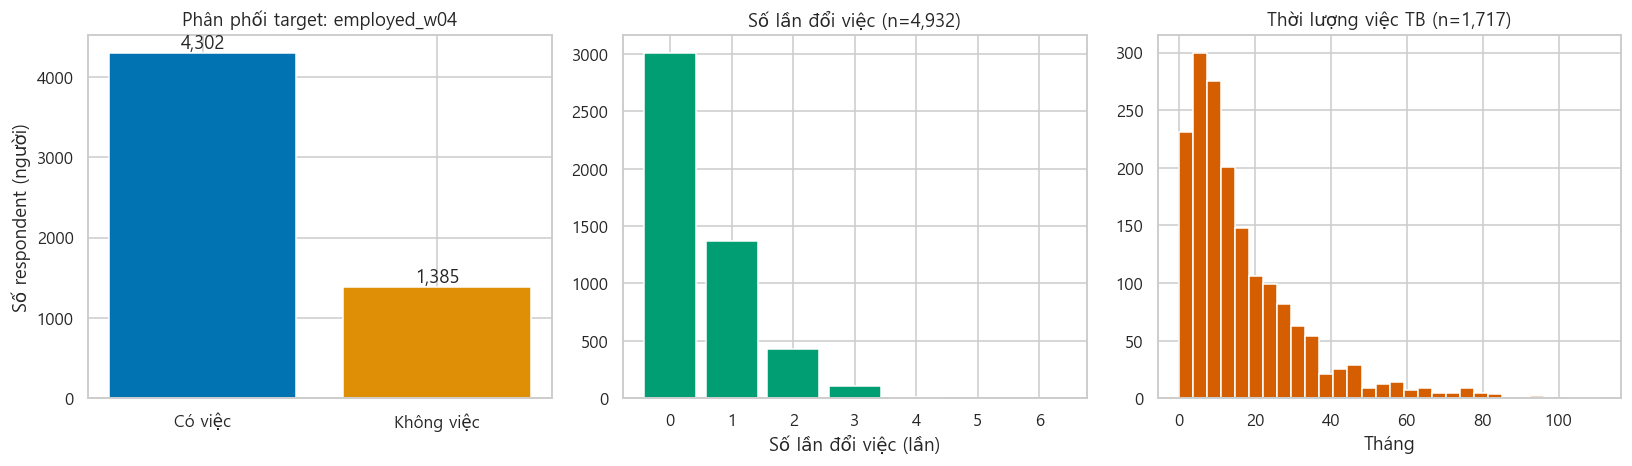

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
emp = df[TARGET].map({True: 'Có việc', False: 'Không việc'}).value_counts()
axes[0].bar(emp.index, emp.values, color=sns.color_palette('colorblind')[:2])
axes[0].set_title('Phân phối target: employed_w04')
axes[0].set_ylabel('Số respondent (người)')
for i, v in enumerate(emp.values):
    axes[0].text(i, v, f'{v:,}', ha='center', va='bottom')

jc = df['job_changes'].dropna()
axes[1].hist(jc, bins=range(0, int(jc.max()) + 2), color=sns.color_palette('colorblind')[2], align='left', rwidth=0.85)
axes[1].set_title(f'Số lần đổi việc (n={len(jc):,})')
axes[1].set_xlabel('Số lần đổi việc (lần)')

dur = df['avg_job_duration_months'].dropna()
axes[2].hist(dur, bins=30, color=sns.color_palette('colorblind')[3])
axes[2].set_title(f'Thời lượng việc TB (n={len(dur):,})')
axes[2].set_xlabel('Tháng')
show()

Để chạm tới toàn bộ các nhóm đặc trưng một cách có hệ thống — nhân khẩu, học vấn,
ngành, GPA, kỹ năng, nền tảng gia đình — ta quét chúng trong hai lưới small-multiples:
một lưới cho biến phân loại (kèm tỷ lệ khuyết của mỗi biến), một lưới cho biến số. Cách
trình bày này ưu tiên *độ phủ* hơn độ sâu, giúp người đọc nắm bức tranh tổng thể của mẫu
chỉ trong hai hình.


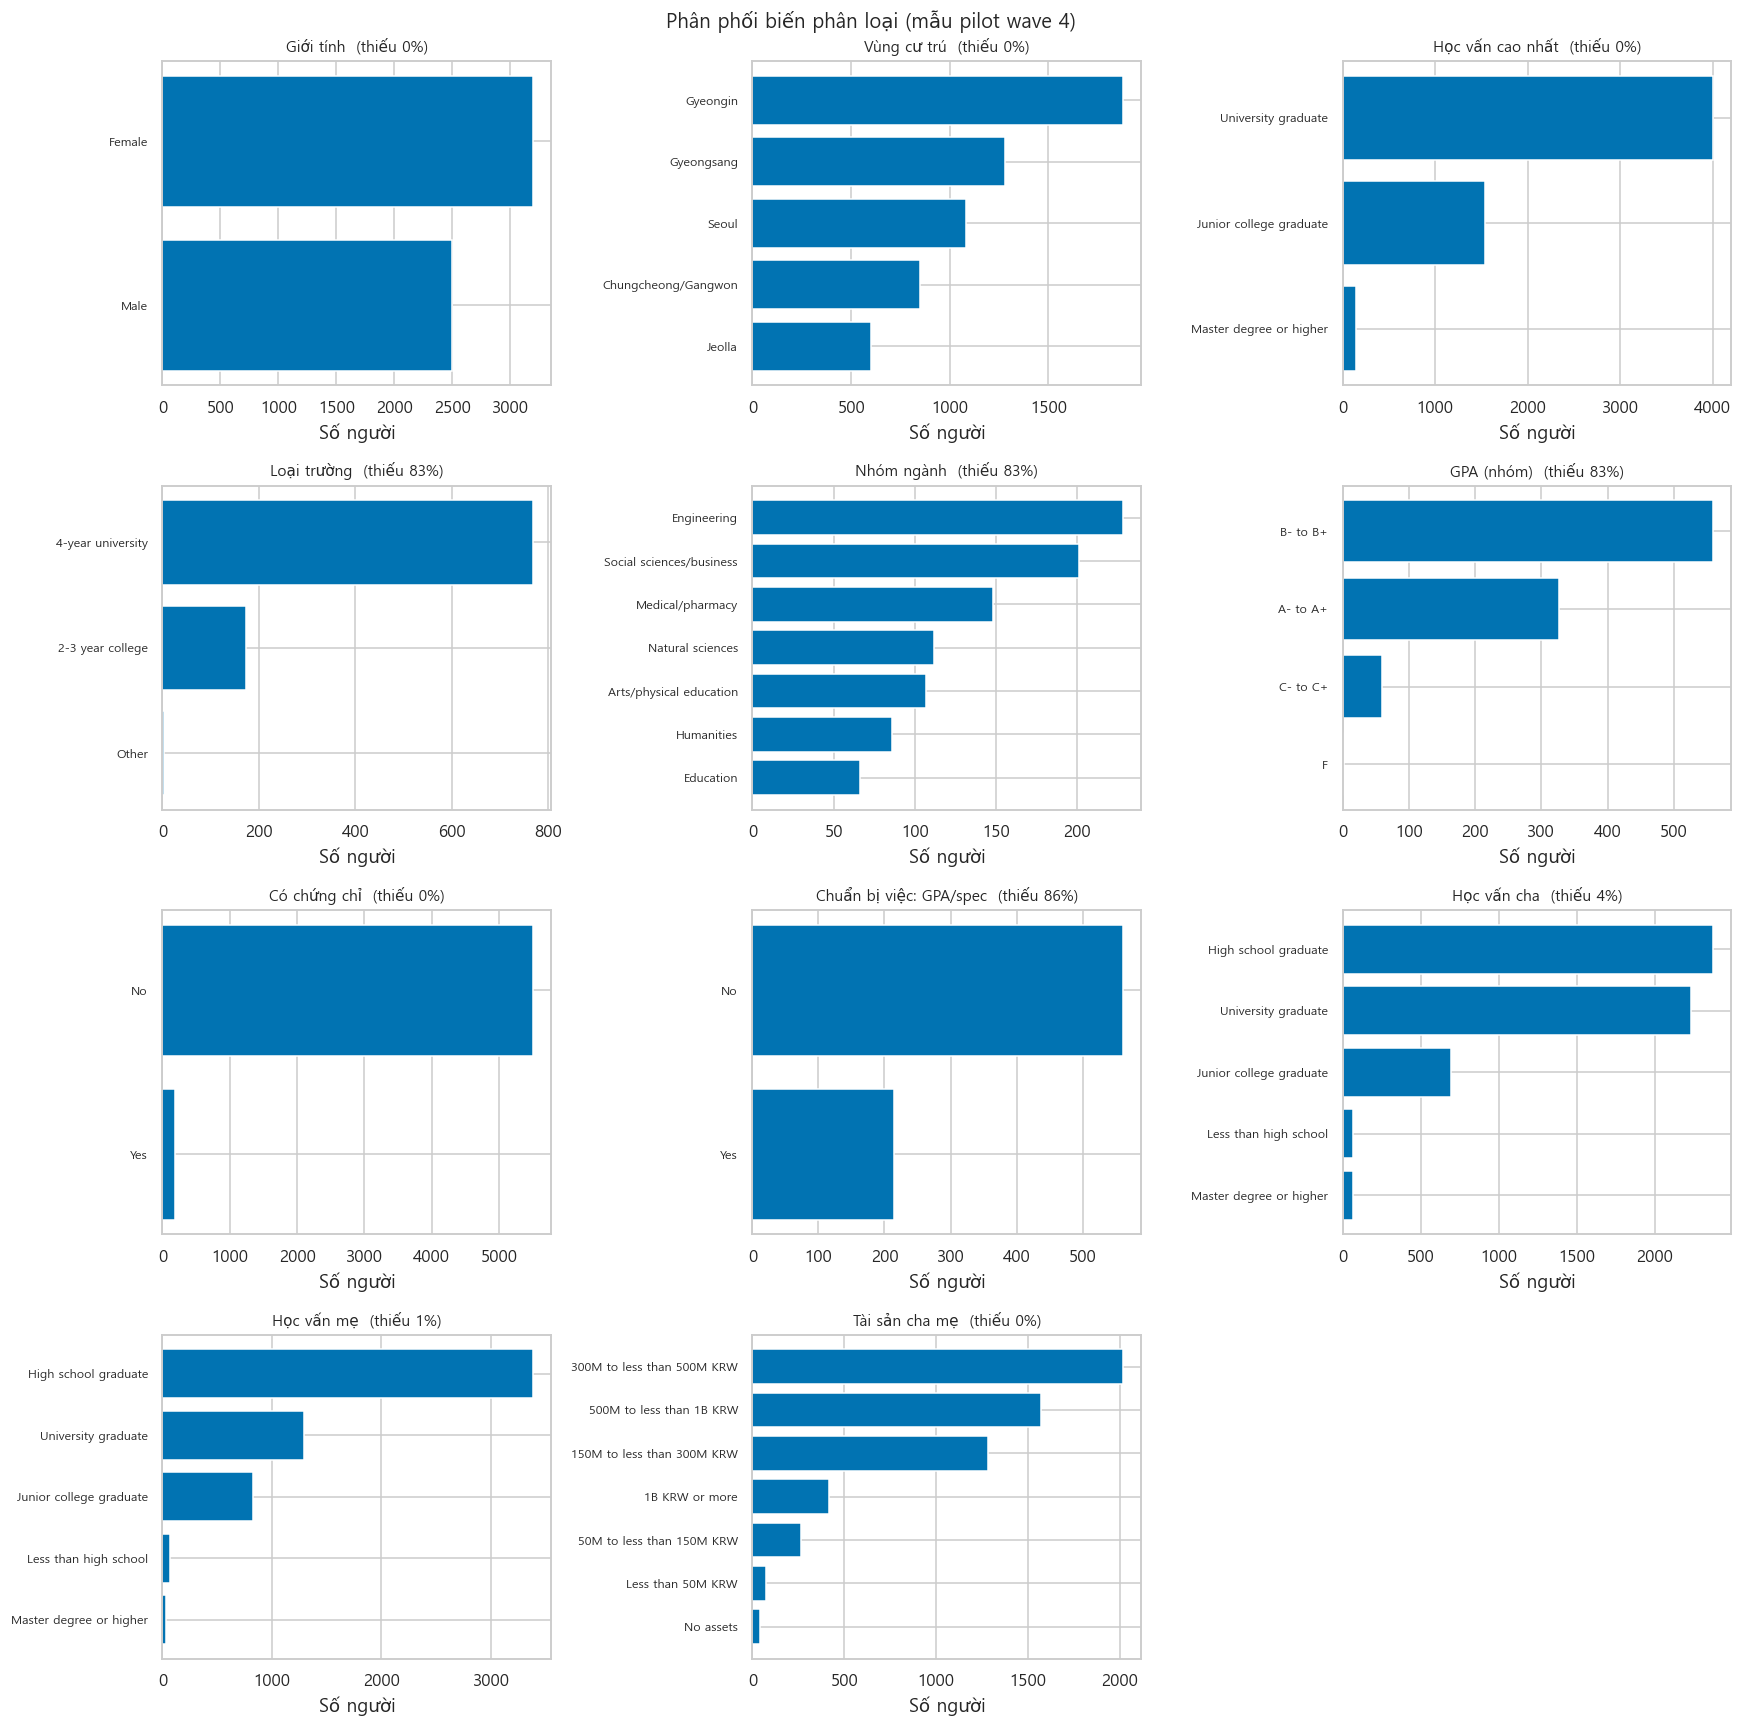

In [14]:
CAT_FEATURES = [
    ('gender_label', 'Giới tính'), ('region_group_w04_label', 'Vùng cư trú'),
    ('education_level_w04_label', 'Học vấn cao nhất'), ('graduate_university_type_label', 'Loại trường'),
    ('graduated_major_field_label', 'Nhóm ngành'), ('graduation_gpa_category_label', 'GPA (nhóm)'),
    ('certificate_earned_label', 'Có chứng chỉ'), ('job_prep_gpa_spec_label', 'Chuẩn bị việc: GPA/spec'),
    ('father_education_label', 'Học vấn cha'), ('mother_education_label', 'Học vấn mẹ'),
    ('parent_asset_bracket_label', 'Tài sản cha mẹ'),
]
NUM_FEATURES = [
    ('age_w04', 'Tuổi (wave 4)'), ('graduation_gpa_yp100', 'GPA YP (thang 100)'),
    ('job_changes', 'Số lần đổi việc'), ('avg_job_duration_months', 'Thời gian TB/việc (tháng)'),
    ('total_jobs', 'Tổng số việc'),
]

ncol = 3
nrow = -(-len(CAT_FEATURES) // ncol)
fig, axes = plt.subplots(nrow, ncol, figsize=(16, 4.0 * nrow))
axes = axes.flatten()
for ax, (col, title) in zip(axes, CAT_FEATURES):
    vc = df[col].value_counts(dropna=True).head(8)[::-1]
    ax.barh(vc.index.astype(str), vc.values, color=sns.color_palette('colorblind')[0])
    ax.set_title(f'{title}  (thiếu {df[col].isna().mean():.0%})', fontsize=10)
    ax.set_xlabel('Số người')
    ax.tick_params(axis='y', labelsize=8)
for ax in axes[len(CAT_FEATURES):]:
    ax.axis('off')
fig.suptitle('Phân phối biến phân loại (mẫu pilot wave 4)', fontsize=13)
show()

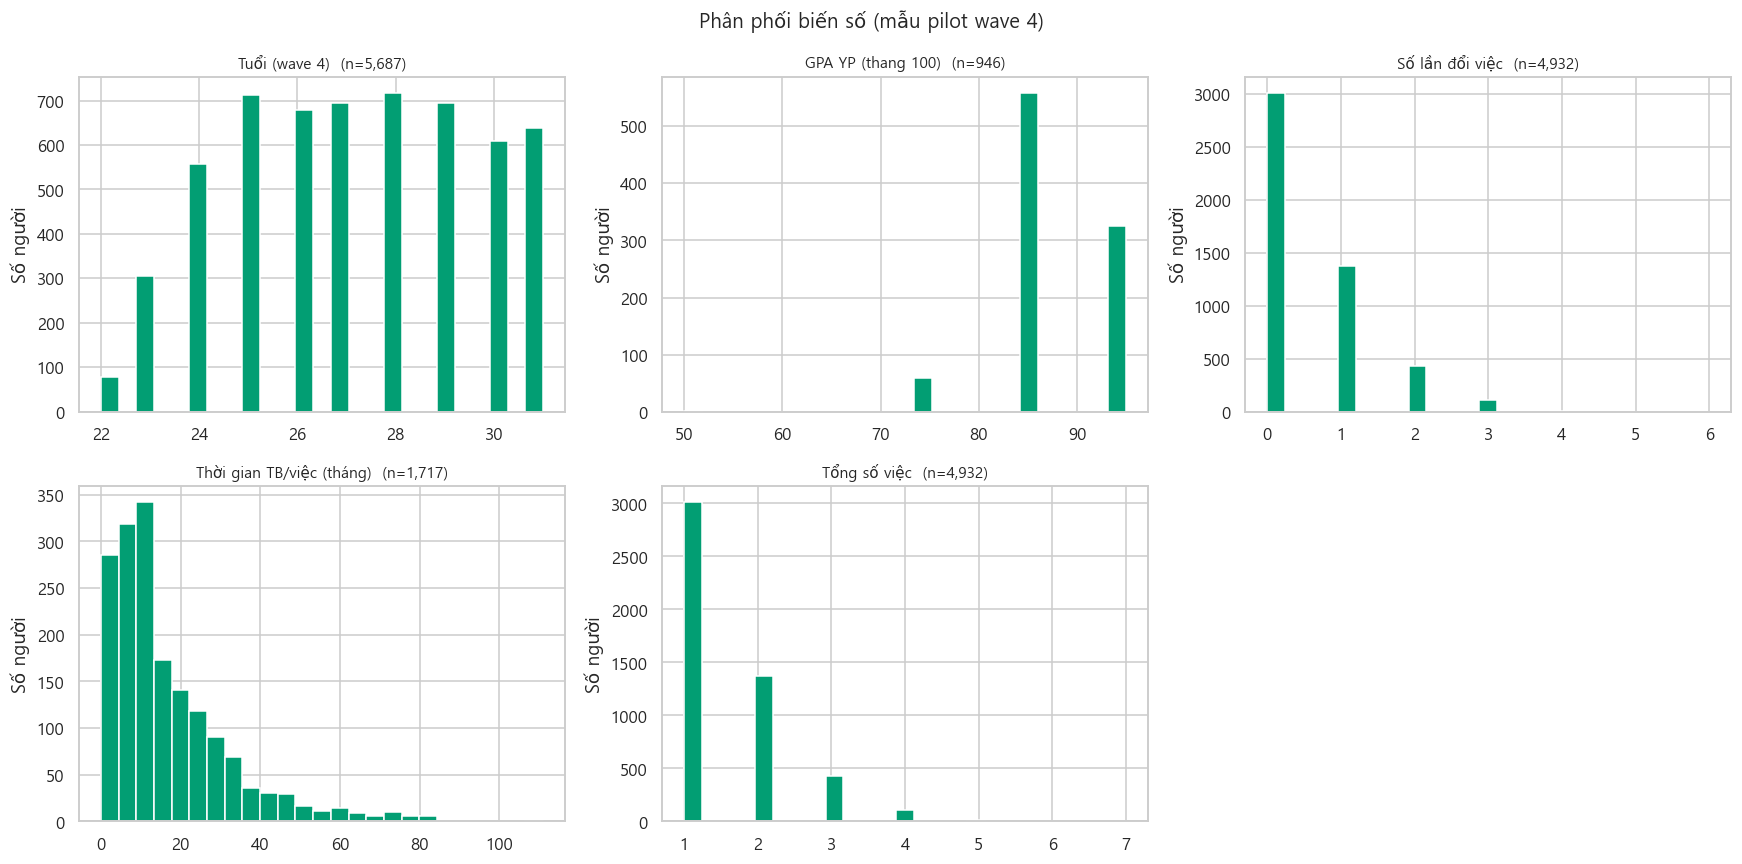

In [15]:
nrow = -(-len(NUM_FEATURES) // ncol)
fig, axes = plt.subplots(nrow, ncol, figsize=(16, 4.0 * nrow))
axes = axes.flatten()
for ax, (col, title) in zip(axes, NUM_FEATURES):
    s = df[col].dropna()
    ax.hist(s, bins=25, color=sns.color_palette('colorblind')[2])
    ax.set_title(f'{title}  (n={len(s):,})', fontsize=10)
    ax.set_ylabel('Số người')
for ax in axes[len(NUM_FEATURES):]:
    ax.axis('off')
fig.suptitle('Phân phối biến số (mẫu pilot wave 4)', fontsize=13)
show()

Một chiều EDA không thể bỏ qua là **độ phủ (coverage)**. Pipeline ghi lại tỷ lệ
giá trị hợp lệ của từng biến processed sau khi đã làm sạch skip code; biểu đồ dưới tô đỏ
các biến phủ dưới 50%. Đây là nhóm ngành, loại trường, GPA và chuẩn bị việc làm — tất cả
thuộc tiểu mô-đun "vừa tốt nghiệp đợt này" chỉ bao khoảng 17% mẫu. Hệ quả trực tiếp là
chúng *không* được đưa vào mô hình lõi, mà chỉ dành cho mô hình nhạy cảm có cờ chỉ báo
khuyết ở Mục 9.


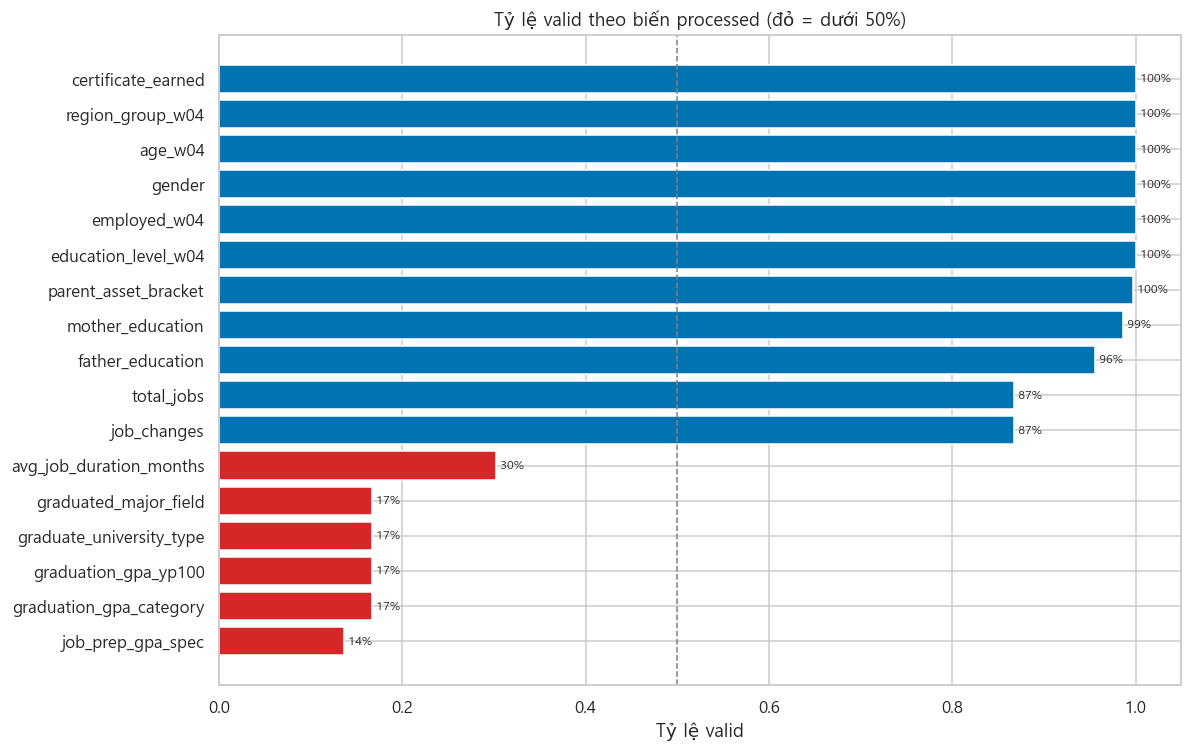

In [16]:
cov = coverage[['group', 'output_column', 'valid_rate', 'valid_count']].sort_values('valid_rate')
fig, ax = plt.subplots(figsize=(11, 7))
colors = ['#d62728' if r < 0.5 else sns.color_palette('colorblind')[0] for r in cov['valid_rate']]
ax.barh(cov['output_column'], cov['valid_rate'], color=colors)
ax.axvline(0.5, color='grey', ls='--', lw=1)
ax.set_title('Tỷ lệ valid theo biến processed (đỏ = dưới 50%)')
ax.set_xlabel('Tỷ lệ valid')
for y, v in enumerate(cov['valid_rate']):
    ax.text(v, y, f' {v:.0%}', va='center', fontsize=8)
show()

## 6. EDA chuyên sâu: khung Bernoulli/Binomial, phân phối lý thuyết, biến đổi

Trước khi xếp hạng liên hệ và mô hình hóa, ta nhìn outcome và các biến số qua lăng kính
xác suất chặt chẽ hơn. Phần này tái dùng module `src.visualization.yp2021_deep_eda` (đã
test), khớp với `reports/yp2021_deep_eda_summary.md`.

**Khung Bernoulli/Binomial.** `employed_w04` là biến **Bernoulli**: mỗi người là một
phép thử có/không việc với xác suất `p̂`. Trên `n` người, số người có việc tuân theo
**Binomial(n, p̂)**. Khung này làm rõ một mốc tham chiếu thiết yếu — **majority baseline
accuracy**: độ chính xác mà một mô hình hằng số (luôn đoán lớp đa số) đã đạt được, và là
ngưỡng mọi mô hình thật phải vượt.


In [17]:
from src.visualization import yp2021_deep_eda as de

framing = de.target_framing(df)
display(framing)

overall = float(df[TARGET].astype(int).mean())
base_acc = float(framing.set_index('quantity').loc['majority-baseline accuracy', 'value'])
print(f'Lớp đa số: "employed" · majority-baseline accuracy = {base_acc:.4f}')
print('⇒ Vì baseline đã đạt accuracy cao nhờ mẫu lệch, ta đánh giá model bằng ROC-AUC/PR, không chỉ accuracy.')

,quantity,value
0,n (Bernoulli trials),5687
1,k (successes = employed),4302
2,p_hat (success prob),0.756462
3,Binomial mean count = n*p,4302.0
4,Binomial std count = sqrt(n*p*(1-p)),32.368
5,rate SE = sqrt(p(1-p)/n),0.005692
6,majority class,employed
7,majority-baseline accuracy,0.756462


Lớp đa số: "employed" · majority-baseline accuracy = 0.7565
⇒ Vì baseline đã đạt accuracy cao nhờ mẫu lệch, ta đánh giá model bằng ROC-AUC/PR, không chỉ accuracy.


**Nhận diện phân phối lý thuyết.** Với mỗi biến số, ta đọc độ lệch (skewness), độ
nhọn vượt (excess kurtosis) và kiểm định Shapiro để gắn cờ *ứng viên Normal*. Quy tắc
thực dụng: |skew| < 0,5 và |excess kurtosis| < 1 thì coi là gần Gauss. Bảng dưới xác nhận
tuổi gần đối xứng, còn các biến đếm việc làm lệch phải rõ — không phải Normal.


In [18]:
dist = de.distribution_identification(df)
display(dist)

,feature,feature_label,n,mean,std,skewness,excess_kurtosis,shapiro_p,normal_candidate,verdict
0,age_w04,Tuổi (wave 4),5687,27.1932,2.4583,-0.0842,-1.0424,5.305896e-38,False,Non-normal (lệch/đuôi)
1,graduation_gpa_yp100,GPA YP (thang 100),946,87.7484,5.9809,-0.5796,2.4246,1.798308e-36,False,Non-normal (lệch/đuôi)
2,job_changes,Số lần đổi việc,4932,0.5272,0.7644,1.4887,2.1547,1.964577e-69,False,Non-normal (lệch/đuôi)
3,avg_job_duration_months,Thời gian TB/việc (tháng),1717,16.8798,15.5852,1.8903,4.5688,7.089739e-40,False,Non-normal (lệch/đuôi)
4,total_jobs,Tổng số việc,4932,1.5272,0.7644,1.4887,2.1547,1.964577e-69,False,Non-normal (lệch/đuôi)


**Ứng viên biến đổi (transformation candidates).** Với biến lệch phải, một phép
`log1p` hoặc `sqrt` thường kéo độ lệch về gần 0, giúp biến phù hợp hơn với các mô hình
giả định tuyến tính/Gauss. Module thử cả hai và chọn phép cho |skew| nhỏ nhất; biểu đồ
dưới đặt cạnh nhau |skew| trước và sau biến đổi đề xuất.


,feature,feature_label,raw_skew,skew_log1p,skew_sqrt,recommended_transform,skew_after,needs_transform
0,avg_job_duration_months,Thời gian TB/việc (tháng),1.8903,-0.3426,0.6365,log1p,-0.3426,True
1,total_jobs,Tổng số việc,1.4887,0.9998,1.0988,log1p,0.9998,True
2,job_changes,Số lần đổi việc,1.4887,0.8423,0.6844,sqrt,0.6844,True
3,graduation_gpa_yp100,GPA YP (thang 100),-0.5796,-1.2095,-0.8541,none,-0.5796,False
4,age_w04,Tuổi (wave 4),-0.0842,-0.2127,-0.1502,none,-0.0842,False


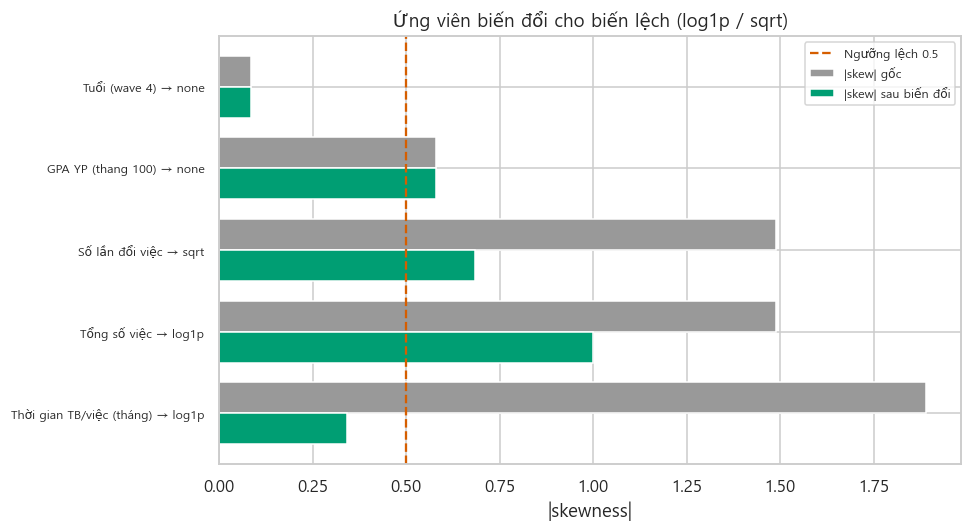

In [19]:
trans = de.transformation_candidates(df)
display(trans)

use_inline()
fig, ax = plt.subplots(figsize=(9, 0.6*len(trans) + 2))
y = np.arange(len(trans)); width = 0.38
ax.barh(y + width/2, trans['raw_skew'].abs(), height=width, color='#999999', label='|skew| gốc')
ax.barh(y - width/2, trans['skew_after'].abs(), height=width, color='#009E73', label='|skew| sau biến đổi')
ax.axvline(0.5, color='#D55E00', ls='--', label='Ngưỡng lệch 0.5')
ax.set_yticks(y)
ax.set_yticklabels([f"{r.feature_label} → {r.recommended_transform}" for r in trans.itertuples()], fontsize=8)
ax.set_xlabel('|skewness|'); ax.set_title('Ứng viên biến đổi cho biến lệch (log1p / sqrt)')
ax.legend(fontsize=8)
show()

## 7. Mối liên hệ giữa đặc trưng và outcome

Bước bản lề giữa khám phá và mô hình hóa là đo *cường độ* liên hệ giữa mỗi đặc trưng với
việc có việc làm. Lưới dưới đây vẽ tỷ lệ có việc theo từng biến phân loại, với đường nét
đứt là mức trung bình chung của mẫu; khoảng cách giữa các thanh so với đường này cho biết
biến đó phân tách outcome mạnh hay yếu. Cần nhấn mạnh: mọi chênh lệch ở đây là **liên hệ
thống kê trong mẫu**, không phải bằng chứng nhân quả.


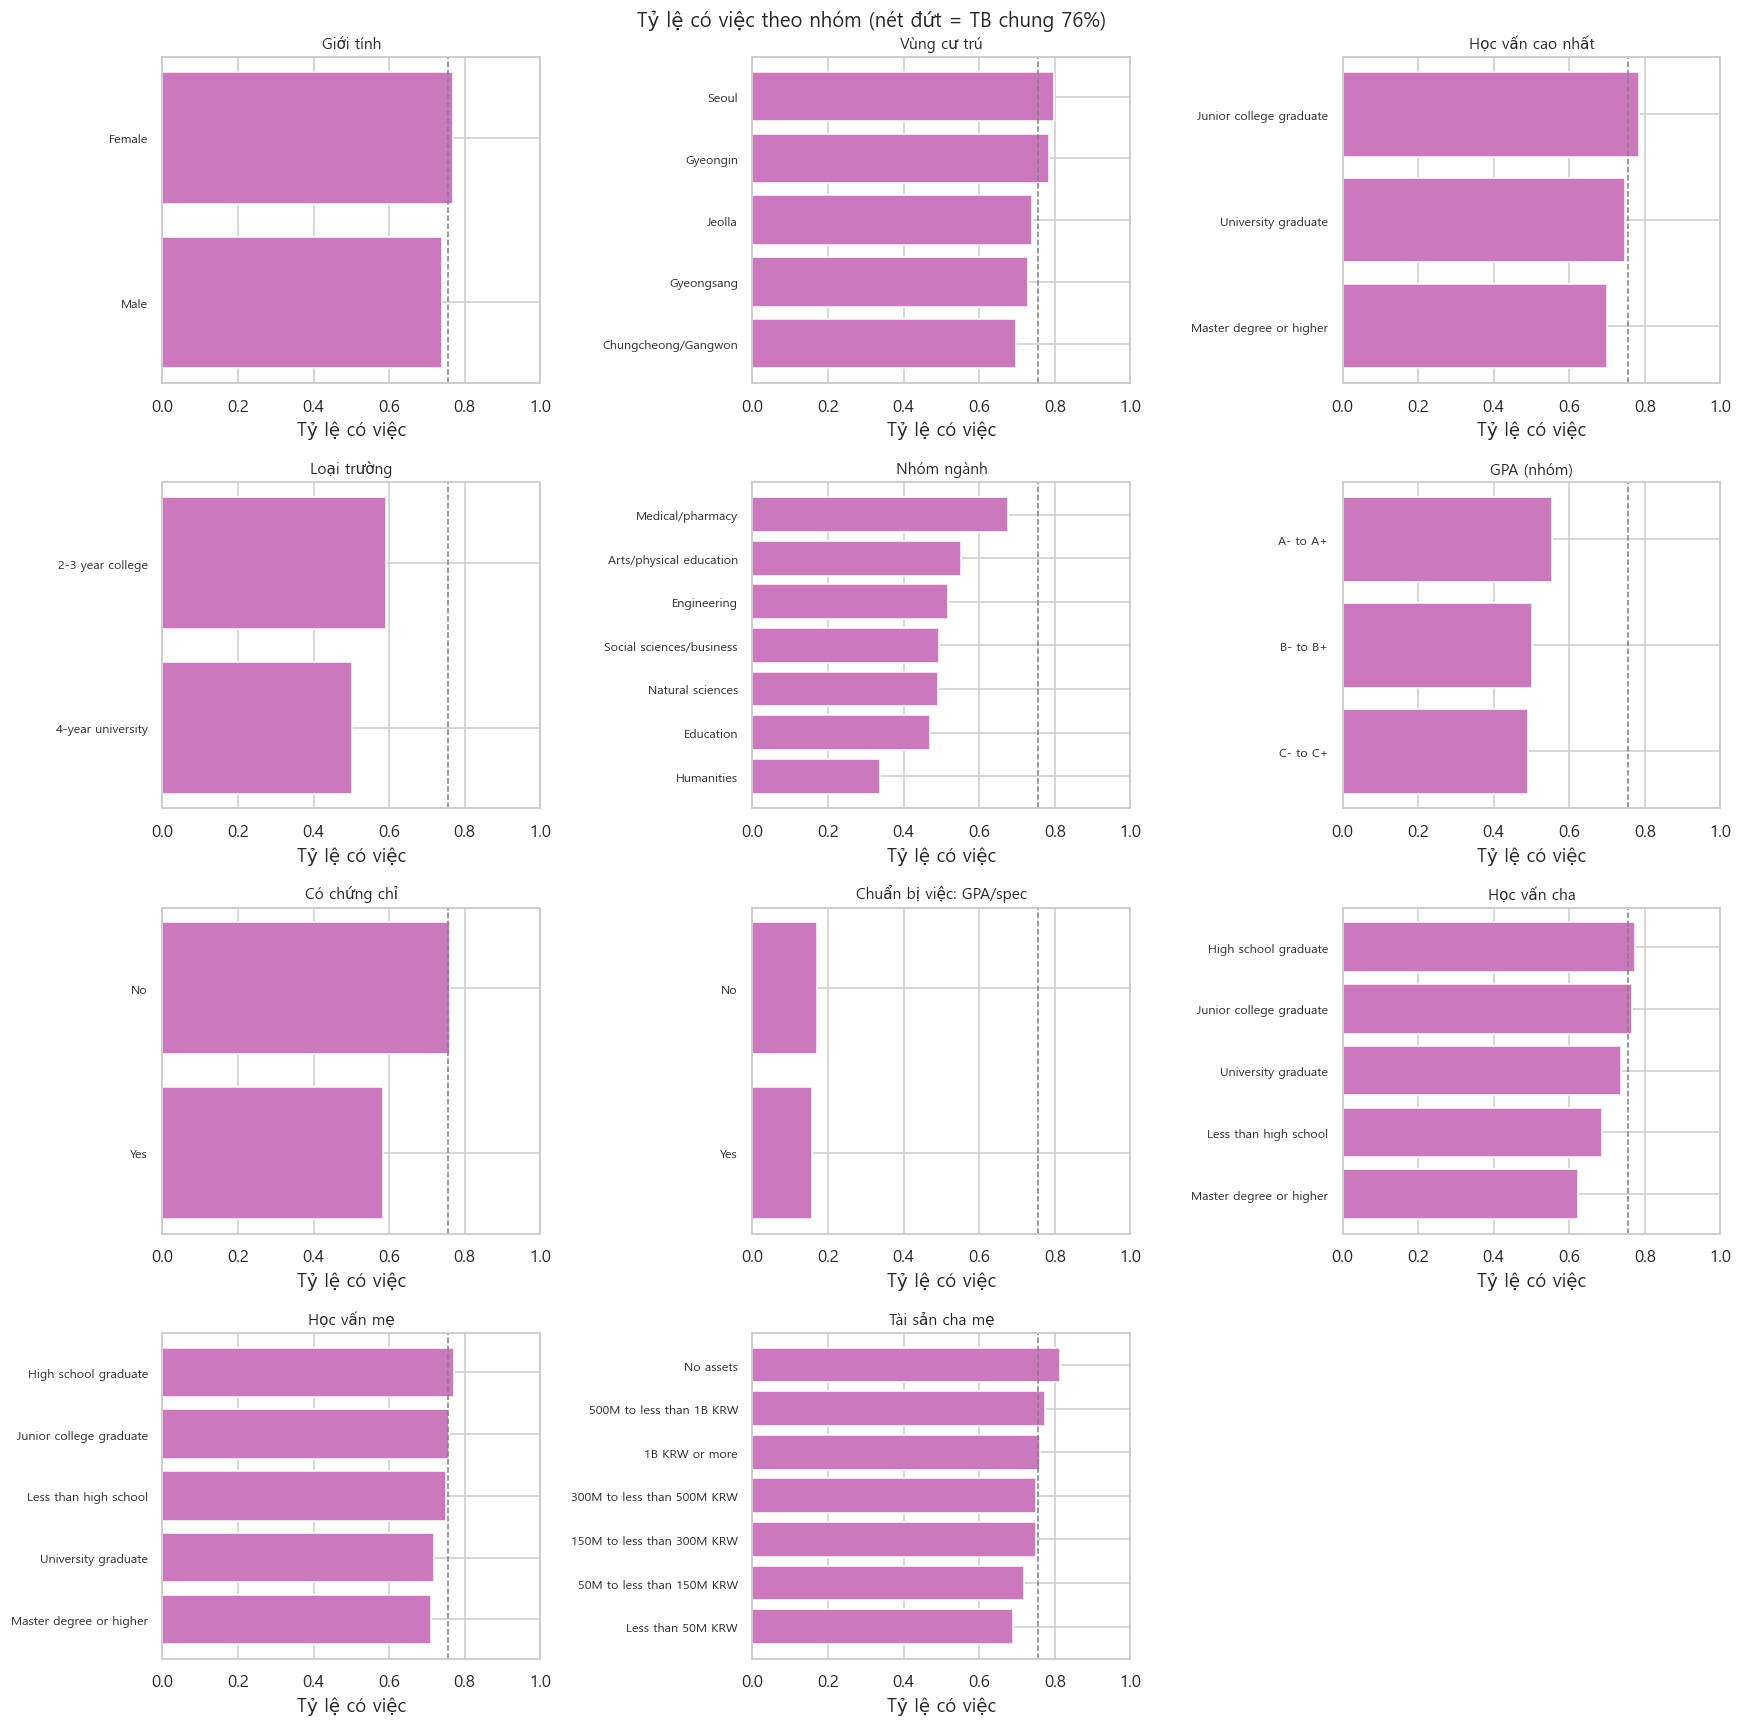

In [20]:
ncol = 3
nrow = -(-len(CAT_FEATURES) // ncol)
fig, axes = plt.subplots(nrow, ncol, figsize=(16, 4.0 * nrow))
axes = axes.flatten()
base = df[TARGET].mean()
for ax, (col, title) in zip(axes, CAT_FEATURES):
    g = (df.dropna(subset=[col]).groupby(col)[TARGET].agg(['mean', 'count']).sort_values('mean'))
    g = g[g['count'] >= 20]
    ax.barh(g.index.astype(str), g['mean'], color=sns.color_palette('colorblind')[4])
    ax.axvline(base, color='grey', ls='--', lw=1)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Tỷ lệ có việc')
    ax.set_xlim(0, 1)
    ax.tick_params(axis='y', labelsize=8)
for ax in axes[len(CAT_FEATURES):]:
    ax.axis('off')
fig.suptitle(f'Tỷ lệ có việc theo nhóm (nét đứt = TB chung {base:.0%})', fontsize=13)
show()

Để kiểm chứng những khác biệt trực quan có vượt ngưỡng ngẫu nhiên hay không, ta
chạy bộ **kiểm định thống kê**: Welch t-test cho biến số đối chiếu hai nhóm có/không
việc, và chi-square cho biến phân loại. Tuổi nổi lên là biến phân tách mạnh nhất (p cực
nhỏ), theo sau là chứng chỉ, vùng cư trú và các biến job-history; trong khi GPA và chuẩn
bị việc làm không đạt ý nghĩa ở mức 5%, phần nào do cỡ mẫu hợp lệ nhỏ.


In [21]:
tests = []
for col in NUMERIC_FEATURES:
    a = df.loc[df[TARGET].eq(True), col].dropna()
    b = df.loc[df[TARGET].eq(False), col].dropna()
    if len(a) >= 2 and len(b) >= 2:
        t, p = stats.ttest_ind(a, b, equal_var=False)
        tests.append({'test': 'welch_t', 'feature': col, 'p_value': p,
                      'mean_employed': round(a.mean(), 3), 'mean_not': round(b.mean(), 3)})
for col, _ in CAT_FEATURES:
    tab = pd.crosstab(df[col], df[TARGET])
    if tab.shape[0] >= 2 and tab.shape[1] == 2 and (tab.values >= 5).all():
        chi2, p, dof, _ = stats.chi2_contingency(tab)
        tests.append({'test': 'chi_square', 'feature': col, 'p_value': p, 'statistic': round(chi2, 2), 'dof': dof})
tests_df = pd.DataFrame(tests)
tests_df['significant_05'] = tests_df['p_value'] < 0.05
print(f"Welch t-test: {(tests_df['test']=='welch_t').sum()} | "
      f"chi-square: {(tests_df['test']=='chi_square').sum()} (đạt yêu cầu ≥3 mỗi loại)")
display(tests_df.sort_values('p_value').round(6))

Welch t-test: 5 | chi-square: 9 (đạt yêu cầu ≥3 mỗi loại)


,test,feature,p_value,mean_employed,mean_not,statistic,dof,significant_05
0,welch_t,age_w04,0.000000,27.529,26.149,NaN,NaN,True
9,chi_square,certificate_earned_label,0.000000,NaN,NaN,30.65,1.0,True
6,chi_square,region_group_w04_label,0.000000,NaN,NaN,39.58,4.0,True
2,welch_t,job_changes,0.000000,0.548,0.384,NaN,NaN,True
4,welch_t,total_jobs,0.000000,1.548,1.384,NaN,NaN,True
3,welch_t,avg_job_duration_months,0.000000,17.651,12.803,NaN,NaN,True
8,chi_square,graduated_major_field_label,0.000097,NaN,NaN,27.94,6.0,True
11,chi_square,father_education_label,0.001714,NaN,NaN,17.27,4.0,True
7,chi_square,education_level_w04_label,0.004493,NaN,NaN,10.81,2.0,True
12,chi_square,mother_education_label,0.006944,NaN,NaN,14.11,4.0,True


Hai heatmap tổng hợp toàn bộ cấu trúc liên hệ vào một khung nhìn. Bản thứ nhất là
**ma trận tương quan Pearson** giữa các biến số, gồm cả target ở dạng 0/1 — nó vừa cho
thấy biến nào liên hệ với outcome, vừa cảnh báo các cặp đặc trưng tự tương quan (chẳng
hạn số lần đổi việc và tổng số việc gần như trùng nhau). Bản thứ hai quy mọi đặc trưng —
số lẫn phân loại — về **một thang cường độ chung** (point-biserial cho biến số, Cramér's
V cho biến phân loại) để xếp hạng mức liên hệ với việc có việc làm.


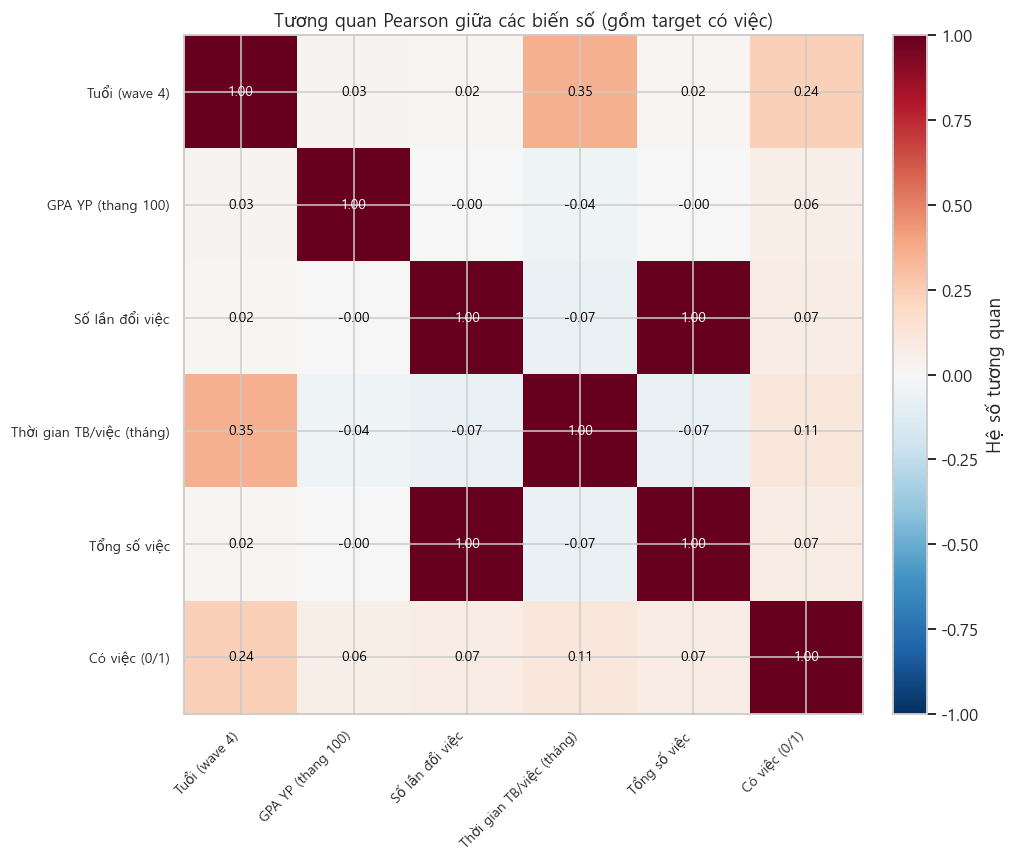

In [22]:
from src.visualization.yp2021_correlation import numeric_correlation, feature_target_association, NUMERIC_LABELS

use_inline()
corr = numeric_correlation(df)
assoc = feature_target_association(df)

labels = [NUMERIC_LABELS.get(c, c) for c in corr.columns]
m = len(corr)
fig, ax = plt.subplots(figsize=(1.1 * m + 2.5, 1.0 * m + 2.0))
im = ax.imshow(corr.to_numpy(), cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(m)); ax.set_yticks(range(m))
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(labels, fontsize=9)
for i in range(m):
    for j in range(m):
        val = corr.to_numpy()[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                color='white' if abs(val) > 0.55 else 'black', fontsize=9)
ax.set_title('Tương quan Pearson giữa các biến số (gồm target có việc)')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Hệ số tương quan')
show()

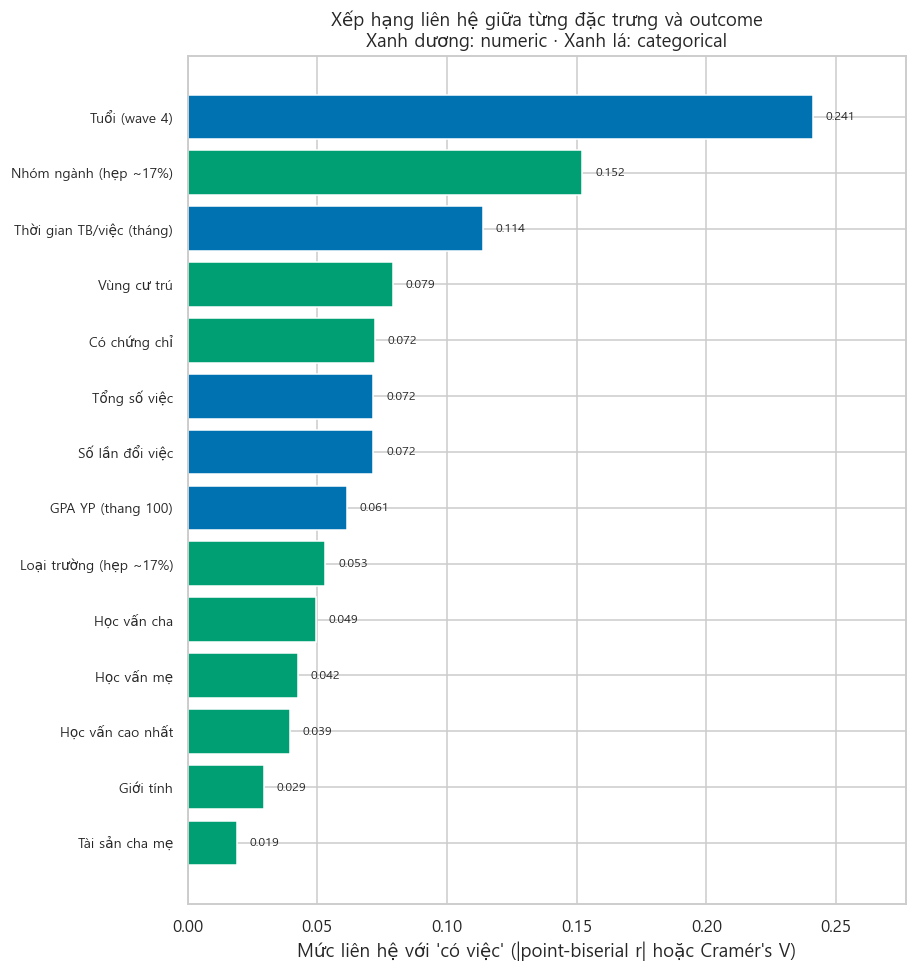

In [23]:
a = assoc.sort_values('strength')
colors = ['#0072B2' if k == 'numeric' else '#009E73' for k in a['kind']]
fig, ax = plt.subplots(figsize=(8.5, 0.5 * len(a) + 2.0))
ax.barh(range(len(a)), a['strength'], color=colors)
ax.set_yticks(range(len(a)))
ax.set_yticklabels(a['label'], fontsize=9)
for i, (_, row) in enumerate(a.iterrows()):
    ax.text(row['strength'] + 0.005, i, f"{row['strength']:.3f}", va='center', fontsize=8)
ax.set_xlabel("Mức liên hệ với 'có việc' (|point-biserial r| hoặc Cramér's V)")
ax.set_title('Xếp hạng liên hệ giữa từng đặc trưng và outcome\nXanh dương: numeric · Xanh lá: categorical')
ax.set_xlim(0, max(0.2, a['strength'].max() * 1.15))
show()

Xếp hạng thô ở trên dễ dẫn tới **overclaim** nếu không kèm độ bất định. Bảng
subgroup dưới đây — lấy từ `deep_eda.subgroup_ranking` — gắn mỗi nhóm một **khoảng tin
cậy Wilson 95%** và một **tầng độ chắc**: 🔵 *vững* khi khác biệt có ý nghĩa thống kê
**và** CI không chứa tỷ lệ chung; 🟡 *thận trọng* khi CI chồng tỷ lệ chung hoặc khi nhóm
thuộc tiểu mẫu chọn lọc ~17% (ngành/GPA/loại trường); 🟢 khi không khác chung. Cách phân
tầng này chặn việc thổi phồng một chênh lệch nhỏ thành "phát hiện".


In [24]:
ranking = de.subgroup_ranking(df)
cols = ['feature_label', 'subgroup', 'n', 'employed_rate', 'wilson_ci_low',
        'wilson_ci_high', 'rate_minus_overall', 'cramers_v', 'confidence_tier']
display(ranking[cols].head(14))

,feature_label,subgroup,n,employed_rate,wilson_ci_low,wilson_ci_high,rate_minus_overall,cramers_v,confidence_tier
0,graduated_major_field_label,Humanities,86,0.3372,0.2462,0.4422,-0.4193,0.1522,🟡 thận trọng (selection bias)
1,graduated_major_field_label,Education,66,0.4697,0.3543,0.5884,-0.2868,0.1522,🟡 thận trọng (selection bias)
2,graduated_major_field_label,Natural sciences,112,0.4911,0.4003,0.5824,-0.2654,0.1522,🟡 thận trọng (selection bias)
3,graduated_major_field_label,Social sciences/business,201,0.4925,0.4242,0.5611,-0.2639,0.1522,🟡 thận trọng (selection bias)
4,graduated_major_field_label,Engineering,228,0.5175,0.4529,0.5816,-0.2389,0.1522,🟡 thận trọng (selection bias)
5,graduated_major_field_label,Arts/physical education,107,0.5514,0.4570,0.6422,-0.2051,0.1522,🟡 thận trọng (selection bias)
6,graduated_major_field_label,Medical/pharmacy,148,0.6757,0.5966,0.7458,-0.0808,0.1522,🟡 thận trọng (selection bias)
7,Vùng cư trú,Chungcheong/Gangwon,847,0.6978,0.6660,0.7277,-0.0587,0.0791,🔵 vững (test + CI tách overall)
8,Vùng cư trú,Seoul,1082,0.7967,0.7717,0.8196,0.0402,0.0791,🔵 vững (test + CI tách overall)
9,Vùng cư trú,Gyeongsang,1281,0.7283,0.7033,0.7520,-0.0281,0.0791,🔵 vững (test + CI tách overall)


Cuối cùng, một heatmap **liên hệ đa biến giữa các predictor với nhau** (không phải
với target): cặp có Cramér's V cao nghĩa là hai biến trùng thông tin → đa cộng tuyến,
gợi ý nên lược bớt khi mô hình hóa. Đây là phần bổ trợ cho cảnh báo `total_jobs ≈
job_changes + 1` đã thấy ở ma trận Pearson.


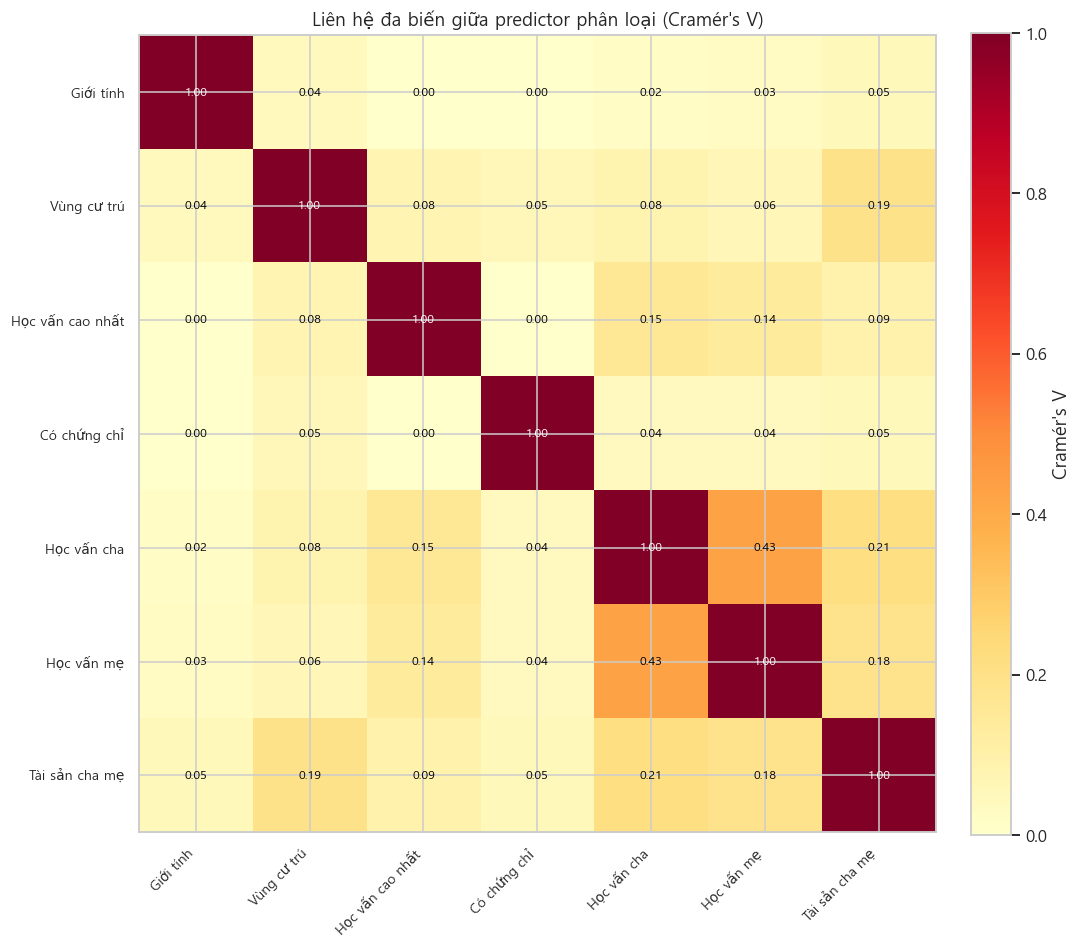

In [25]:
multi = de.multivariate_association(df)
use_inline()
mlabels = [de.CATEGORICAL_FEATURES.get(c, c) for c in multi.columns]
mm = len(multi); arr = multi.to_numpy(dtype=float)
fig, ax = plt.subplots(figsize=(1.0*mm + 3, 1.0*mm + 2.5))
im = ax.imshow(arr, cmap='YlOrRd', vmin=0, vmax=1)
ax.set_xticks(range(mm)); ax.set_yticks(range(mm))
ax.set_xticklabels(mlabels, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(mlabels, fontsize=9)
for i in range(mm):
    for j in range(mm):
        ax.text(j, i, f'{arr[i, j]:.2f}', ha='center', va='center',
                color='white' if arr[i, j] > 0.5 else 'black', fontsize=8)
ax.set_title("Liên hệ đa biến giữa predictor phân loại (Cramér's V)")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Cramér's V")
show()

## 8. Catalog đặc trưng, kiểm toán sẵn sàng và checklist chống rò rỉ

Trước khi mô hình hóa, ta lập một **catalog đặc trưng** có hệ thống: mỗi biến ứng viên đi
kèm vai trò (core / narrow-scope / loại vì leakage), kiểu dữ liệu, độ phủ, chiến lược
điền khuyết – mã hóa – chuẩn hoá, và đánh giá rò rỉ. Catalog này sinh trực tiếp từ
`src.models.youth_panel.feature_catalog` (lấy nguồn từ các tuple CORE/LEAKAGE/NARROW_SCOPE
trong `dataset.py`), nên **không thể lệch** khỏi tập đặc trưng mô hình thực dùng.


In [26]:
from src.models.youth_panel import feature_catalog as fc

catalog = fc.build_catalog(df)
view = catalog[['feature', 'group', 'role', 'dtype_kind', 'coverage',
                'imputation', 'encoding', 'scaling', 'used_in_core_model']]
display(view)

n_core = int(catalog['used_in_core_model'].sum())
n_excluded = int((catalog['role'] == 'excluded_leakage').sum())
print(f'{n_core} đặc trưng vào model core · {n_excluded} cột loại vì leakage (đo SAU khi có việc).')

,feature,group,role,dtype_kind,coverage,imputation,encoding,scaling,used_in_core_model
0,age_w04,Demographics,core_feature,numeric,1.0000,median (SimpleImputer),—,StandardScaler,True
1,gender_label,Demographics,core_feature,categorical,1.0000,constant 'missing',OneHotEncoder(handle_unknown='ignore'),—,True
2,region_group_w04_label,Demographics,core_feature,categorical,1.0000,constant 'missing',OneHotEncoder(handle_unknown='ignore'),—,True
3,education_level_w04_label,Education level,core_feature,categorical,1.0000,constant 'missing',OneHotEncoder(handle_unknown='ignore'),—,True
4,certificate_earned_label,Education level,core_feature,categorical,1.0000,constant 'missing',OneHotEncoder(handle_unknown='ignore'),—,True
5,father_education_label,Family background,core_feature,categorical,0.9555,constant 'missing',OneHotEncoder(handle_unknown='ignore'),—,True
6,mother_education_label,Family background,core_feature,categorical,0.9858,constant 'missing',OneHotEncoder(handle_unknown='ignore'),—,True
7,parent_asset_bracket_label,Family background,core_feature,categorical,0.9974,constant 'missing',OneHotEncoder(handle_unknown='ignore'),—,True
8,graduated_major_field_label,Detailed education (narrow ~17%),narrow_scope_sensitivity,categorical,0.1667,constant 'missing',OneHotEncoder(handle_unknown='ignore'),—,False
9,graduate_university_type_label,Detailed education (narrow ~17%),narrow_scope_sensitivity,categorical,0.1663,constant 'missing',OneHotEncoder(handle_unknown='ignore'),—,False


8 đặc trưng vào model core · 3 cột loại vì leakage (đo SAU khi có việc).


Đi kèm catalog là một **checklist chống rò rỉ (leakage control)** tách riêng — đây
là tuyến phòng thủ then chốt để điểm số mô hình không bị "đẹp giả tạo":

- **Loại biến đo sau outcome.** `total_jobs`, `job_changes`, `avg_job_duration_months`
  đếm việc làm *sau* khi tình trạng việc được quan sát → loại khỏi cả core lẫn narrow.
- **Không dùng cột nguồn của target.** Các cột `employed_w04_source*` (mã sinh ra target)
  không nằm trong tập đặc trưng.
- **Impute/scale/encode bên trong Pipeline.** `StandardScaler`/`SimpleImputer`/
  `OneHotEncoder` chỉ fit trên fold train ở mỗi vòng CV → không rò thống kê test sang train.
- **Chia trước, biến đổi sau.** `train_test_split` (stratify) chạy trước; preprocessor fit
  sau khi đã chia.
- **Narrow-scope cô lập.** Khối ngành/GPA/loại trường (~17%, chọn lọc) chỉ vào model
  `--narrow-scope` kèm cờ chỉ báo khuyết, không impute như MCAR.

Toàn văn checklist nằm ở `reports/data_check/yp2021_feature_readiness_audit.md`.


## 9. Mô hình hóa, đánh giá nâng cao và đánh đổi bias–variance

Bài toán trọng tâm là **phân loại nhị phân**: dự đoán `employed_w04` từ tập đặc trưng đã
tinh lọc theo catalog ở Mục 8. Pipeline (trong `src.models.youth_panel.evaluate`) so bốn
mô hình: một **baseline hằng số** luôn đoán lớp đa số làm mốc; hai **hồi quy logistic** có
điều chuẩn **L2 (Ridge)** và **L1 (Lasso)**; và một **Random Forest** làm mô hình so sánh
phi tuyến nội bộ. Tiền xử lý gói trong `ColumnTransformer`, đánh giá gồm chia stratified
80/20, k-fold cross-validation, và bộ chỉ số đầy đủ trên tập kiểm thử (gồm cả Average
Precision và Brier score).


### 9.1. Kiểm tra bảng "modeling-ready" trước khi huấn luyện

Trước khi fit bất kỳ mô hình nào, ta xác nhận tường minh rằng bảng đầu vào đúng hợp đồng
(contract) — học theo bước kiểm tra modeling-ready của KEEP II. Bốn điều cần chắc: (1)
**độ chi tiết (grain)** là một-dòng-một-người, không trùng `sampid`; (2) **target** đúng
nhị phân 0/1 và đã tách khỏi X; (3) **predictor contract** khớp catalog — không có cột
leakage lọt vào X; (4) **missingness** trước preprocessing nằm trong mức xử lý được bằng
imputer trong pipeline.


In [27]:
from src.models.youth_panel.dataset import (
    build_modeling_data, load_processed_pilot, TARGET as TGT, LEAKAGE_COLUMNS,
)

ready_frame = load_processed_pilot()
mdata = build_modeling_data(ready_frame, include_narrow_scope=False)

checks = []
# (1) grain: một dòng một người
dup = int(ready_frame['sampid'].duplicated().sum()) if 'sampid' in ready_frame.columns else -1
checks.append(('Grain một-dòng-một-người (sampid không trùng)', dup == 0, f'{dup} dòng trùng'))
# (2) target nhị phân, tách khỏi X
y_ok = set(pd.unique(mdata.y)) <= {0, 1}
checks.append(('Target nhị phân 0/1 và đã tách khỏi X', y_ok and TGT not in mdata.X.columns, f'giá trị y = {sorted(set(pd.unique(mdata.y)))}'))
# (3) predictor contract: không có cột leakage trong X
leak_in_X = [c for c in LEAKAGE_COLUMNS if c in mdata.X.columns]
checks.append(('Không có cột leakage trong X', len(leak_in_X) == 0, f'leakage lọt vào: {leak_in_X or "không"}'))
# (4) missingness xử lý được (mọi cột < 100% khuyết; số/đối tượng đều có imputer)
max_missing = float(mdata.X.isna().mean().max())
checks.append(('Missingness < 100% mỗi cột (imputer xử lý được)', max_missing < 1.0, f'cột khuyết nhiều nhất = {max_missing:.1%}'))

ready = pd.DataFrame(checks, columns=['Kiểm tra', 'Đạt', 'Chi tiết'])
display(ready)
assert ready['Đạt'].all(), 'Có kiểm tra modeling-ready KHÔNG đạt — dừng trước khi fit.'
print(f'Tất cả {len(ready)} kiểm tra modeling-ready ĐẠT · X shape = {mdata.X.shape} · #features = {len(mdata.feature_names)}')

,Kiểm tra,Đạt,Chi tiết
0,Grain một-dòng-một-người (sampid không trùng),True,0 dòng trùng
1,Target nhị phân 0/1 và đã tách khỏi X,True,"giá trị y = [np.int64(0), np.int64(1)]"
2,Không có cột leakage trong X,True,leakage lọt vào: không
3,Missingness < 100% mỗi cột (imputer xử lý được),True,cột khuyết nhiều nhất = 4.4%


Tất cả 4 kiểm tra modeling-ready ĐẠT · X shape = (5687, 8) · #features = 8


### 9.2. Bảng metric trên tập kiểm thử

Pipeline (trong `src.models.youth_panel.evaluate`) so bốn mô hình: một **baseline hằng
số** luôn đoán lớp đa số làm mốc; hai **hồi quy logistic** có điều chuẩn **L2 (Ridge)** và
**L1 (Lasso)**; và một **Random Forest** làm mô hình so sánh phi tuyến nội bộ. Tiền xử lý
gói trong `ColumnTransformer`, đánh giá gồm chia stratified 80/20, k-fold cross-validation,
và bộ chỉ số đầy đủ (gồm cả Average Precision và Brier score).


In [28]:
from src.models.youth_panel.evaluate import run_modeling
from src.models.youth_panel.report import MODEL_LABELS, PALETTE

results = run_modeling(mdata)

print(f"Train/test: {results.split_info['n_train']:,} / {results.split_info['n_test']:,} "
      f"| số đặc trưng đầu vào: {results.split_info['n_features_in']}")
cols = ['model', 'test_accuracy', 'test_precision', 'test_recall', 'test_f1',
        'test_roc_auc', 'test_average_precision', 'test_brier_score']
display(results.metrics_frame[cols].round(4))

Train/test: 4,549 / 1,138 | số đặc trưng đầu vào: 8


,model,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,test_average_precision,test_brier_score
0,baseline_most_frequent,0.7566,0.7566,1.0000,0.8614,0.5000,0.7566,0.2434
1,logreg_l2,0.7601,0.7663,0.9826,0.8611,0.6788,0.8547,0.1698
2,logreg_l1,0.7610,0.7665,0.9837,0.8616,0.6789,0.8547,0.1698
3,random_forest,0.6555,0.8443,0.6678,0.7458,0.6812,0.8534,0.2202


### 9.3. Cầu nối toán học: từ log-odds tới loss và gradient descent

Hồi quy logistic ước lượng xác suất có việc qua hàm **sigmoid** trên tổ hợp tuyến tính
của đặc trưng:

$$ z = \beta_0 + \beta_1 x_1 + \dots + \beta_k x_k, \qquad \hat p = \sigma(z) = \frac{1}{1+e^{-z}}, \qquad \ln\frac{\hat p}{1-\hat p} = z. $$

Mỗi hệ số $\beta_j$ chính là **log-odds** (xem biểu đồ 9.6), và $e^{\beta_j}$ là **tỉ số
odds**. Mô hình được huấn luyện bằng cách cực tiểu hoá **cross-entropy loss** (log loss),
tức negative log-likelihood của phân phối Bernoulli:

$$ L(\beta) = -\frac{1}{n}\sum_i \big[ y_i \ln \hat p_i + (1-y_i)\ln(1-\hat p_i) \big]. $$

**Gradient descent** cập nhật tham số theo hướng giảm loss, với gradient có dạng đặc biệt
gọn — *sai số dự đoán* nhân với đặc trưng:

$$ \frac{\partial L}{\partial \beta_j} = \frac{1}{n}\sum_i (\hat p_i - y_i)\, x_{ij}, \qquad \beta \leftarrow \beta - \eta\, \nabla L. $$

sklearn dùng solver `saga` (một biến thể gradient ngẫu nhiên) để giải; tham số $C = 1/\lambda$
điều khiển cường độ điều chuẩn L1/L2. Cuối cùng, **baseline theo loss**: mỗi hàm mất mát
có một hằng số tối ưu riêng — MSE → trung bình, MAE → trung vị, và log loss → tỷ lệ lớp
(prevalence). Vì target nhị phân, baseline đúng là **most-frequent** (luôn đoán "có
việc"), với ROC-AUC = 0.5 — mốc mọi mô hình thật phải vượt về *khả năng phân biệt*, chứ
không chỉ về accuracy.


### 9.4. Ma trận nhầm lẫn và năng lực phân tách

**Ma trận nhầm lẫn** mở bung các con số tổng hợp thành bốn ô quyết định thực tế. Vì mẫu
lệch mạnh về phía có việc, baseline đạt accuracy cao chỉ nhờ luôn đoán "có việc" — nhưng
không phân biệt được ai thất nghiệp. So sánh confusion matrix giữa baseline và các mô
hình thật cho thấy giá trị nằm ở khả năng nhận diện lớp thiểu số, điều mà accuracy đơn lẻ
che giấu.


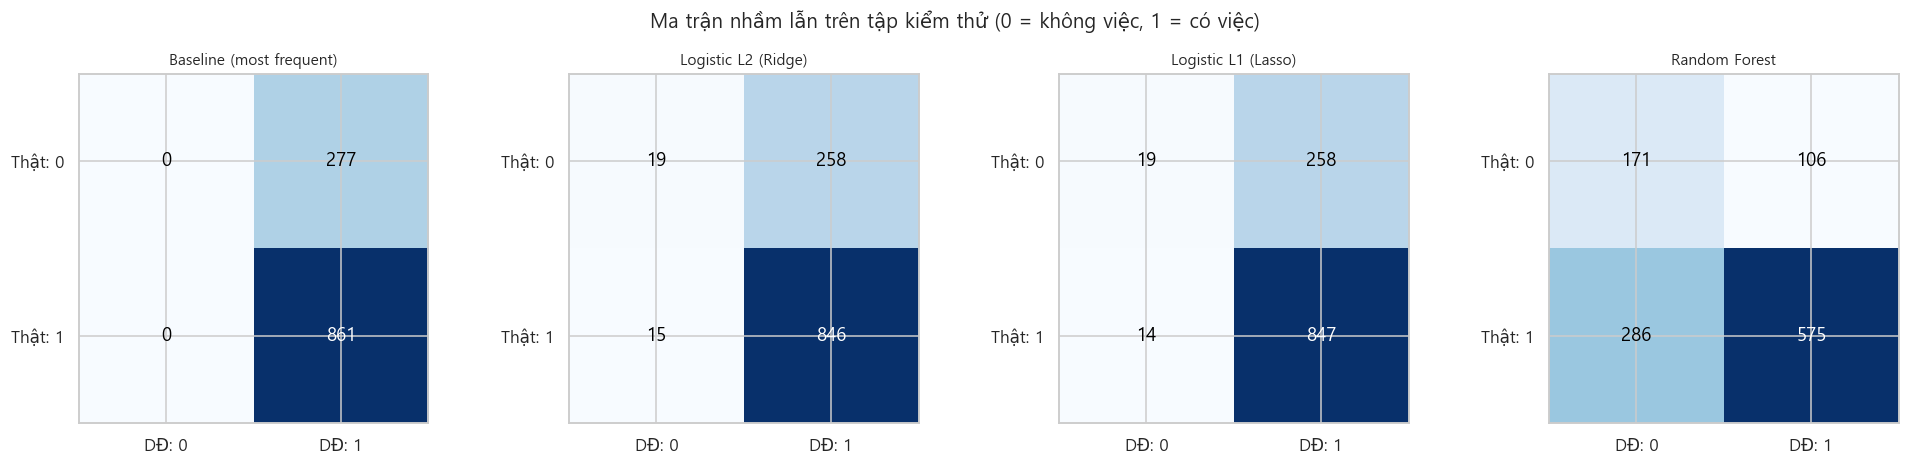

In [29]:
use_inline()
order = ['baseline_most_frequent', 'logreg_l2', 'logreg_l1', 'random_forest']
fig, axes = plt.subplots(1, 4, figsize=(18, 4.2))
for ax, name in zip(axes, order):
    cm = results.models[name].confusion
    ax.imshow(cm, cmap='Blues')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{cm[i, j]:,}', ha='center', va='center',
                    color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=12)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['DĐ: 0', 'DĐ: 1']); ax.set_yticklabels(['Thật: 0', 'Thật: 1'])
    ax.set_title(MODEL_LABELS.get(name, name), fontsize=10)
fig.suptitle('Ma trận nhầm lẫn trên tập kiểm thử (0 = không việc, 1 = có việc)', fontsize=13)
show()

**Đường ROC** và **đường Precision–Recall** đánh giá năng lực phân tách ở mọi
ngưỡng. ROC tóm tắt bằng AUC; PR phù hợp hơn khi lớp lệch vì tập trung vào lớp dương. Các
mô hình thật đều vượt rõ đường tham chiếu ngẫu nhiên, xác nhận tín hiệu thật dù khiêm tốn.


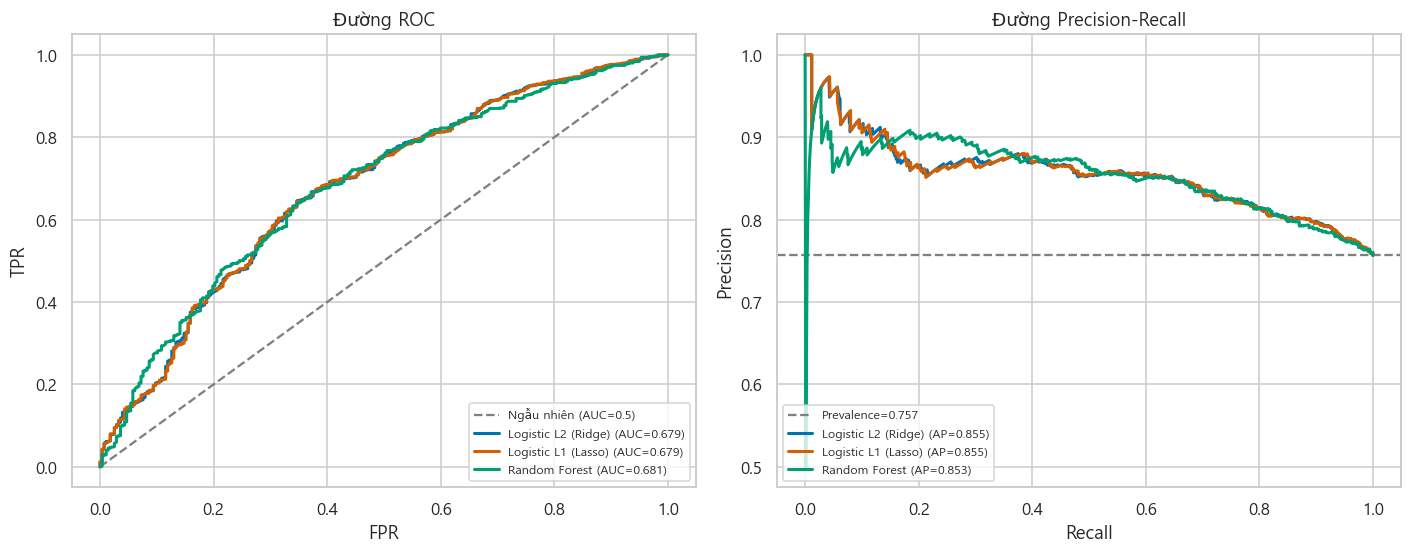

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
ax = axes[0]
ax.plot([0, 1], [0, 1], '--', color='grey', label='Ngẫu nhiên (AUC=0.5)')
for name in ['logreg_l2', 'logreg_l1', 'random_forest']:
    rc = results.models[name].roc_curve
    if rc is not None:
        auc = results.models[name].test_metrics['roc_auc']
        ax.plot(rc[0], rc[1], lw=2, color=PALETTE.get(name), label=f'{MODEL_LABELS[name]} (AUC={auc:.3f})')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.set_title('Đường ROC'); ax.legend(loc='lower right', fontsize=8)

ax = axes[1]
prev = float(results.y_test.mean())
ax.axhline(prev, color='grey', ls='--', label=f'Prevalence={prev:.3f}')
for name in ['logreg_l2', 'logreg_l1', 'random_forest']:
    pr = results.models[name].precision_recall_curve
    if pr is not None:
        ap = results.models[name].test_metrics['average_precision']
        ax.plot(pr[1], pr[0], lw=2, color=PALETTE.get(name), label=f'{MODEL_LABELS[name]} (AP={ap:.3f})')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision'); ax.set_title('Đường Precision-Recall'); ax.legend(loc='lower left', fontsize=8)
show()

**Hiệu chỉnh xác suất (calibration)** kiểm tra xác suất dự đoán có khớp tần suất
quan sát hay không — quan trọng khi dùng xác suất để ra quyết định chứ không chỉ xếp
hạng. **Threshold tuning** cho thấy việc dời ngưỡng quyết định khỏi mặc định 0.5 đánh đổi
precision và recall ra sao, hữu ích khi chi phí hai loại sai khác nhau.


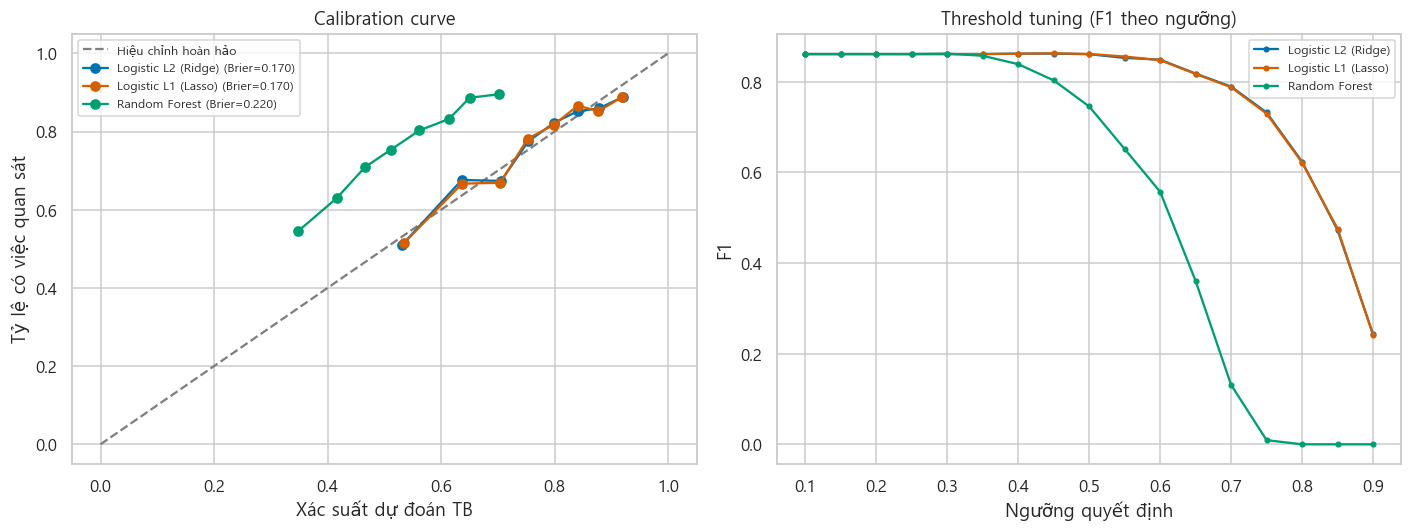

In [31]:
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(1, 2, figsize=(13, 5.0))
ax = axes[0]
ax.plot([0, 1], [0, 1], '--', color='grey', label='Hiệu chỉnh hoàn hảo')
for name in ['logreg_l2', 'logreg_l1', 'random_forest']:
    model = results.models[name]
    obs, pred = calibration_curve(results.y_test, model.y_proba, n_bins=8, strategy='quantile')
    brier = model.test_metrics['brier_score']
    ax.plot(pred, obs, marker='o', color=PALETTE.get(name), label=f'{MODEL_LABELS[name]} (Brier={brier:.3f})')
ax.set_xlabel('Xác suất dự đoán TB'); ax.set_ylabel('Tỷ lệ có việc quan sát')
ax.set_title('Calibration curve'); ax.legend(loc='upper left', fontsize=8)

ax = axes[1]
tf = results.threshold_frame
for name in ['logreg_l2', 'logreg_l1', 'random_forest']:
    part = tf[tf['model'] == name]
    ax.plot(part['threshold'], part['f1'], marker='o', ms=3, color=PALETTE.get(name), label=MODEL_LABELS[name])
ax.set_xlabel('Ngưỡng quyết định'); ax.set_ylabel('F1')
ax.set_title('Threshold tuning (F1 theo ngưỡng)'); ax.legend(fontsize=8)
show()

### 9.5. Hiệu năng theo nhóm (subgroup performance / công bằng)

Một mô hình có thể đạt chỉ số tổng thể tốt nhưng lại hoạt động **không đồng đều giữa các
nhóm** — điều cần kiểm tra trước khi tin dùng. Bảng và biểu đồ dưới đây tách hiệu năng của
mô hình L2 theo **giới tính**, **vùng cư trú** và **học vấn** (chỉ giữ nhóm có n ≥ 30 trên
tập kiểm thử). Số liệu lấy từ `results.subgroup_frame` (khớp
`reports/data_check/yp2021_model_subgroups.csv`). Khoảng dao động của ROC-AUC giữa các
nhóm cho biết mức chênh lệch công bằng; chênh lớn là cờ cần thận trọng khi áp dụng.


In [32]:
sg = results.subgroup_frame
sg_l2 = sg[sg['model'] == 'logreg_l2'].copy()
sg_view = sg_l2[['subgroup_column', 'subgroup_value', 'n', 'actual_positive_rate',
                 'accuracy', 'precision', 'recall', 'f1', 'roc_auc']].round(3)
display(sg_view)

spread = sg_l2.groupby('subgroup_column')['roc_auc'].agg(['min', 'max'])
spread['gap'] = (spread['max'] - spread['min']).round(3)
print('Khoảng dao động ROC-AUC giữa các nhóm (mô hình L2):')
print(spread.round(3).to_string())

,subgroup_column,subgroup_value,n,actual_positive_rate,accuracy,precision,recall,f1,roc_auc
9,gender_label,Female,649,0.758,0.753,0.762,0.982,0.858,0.689
10,gender_label,Male,489,0.755,0.769,0.772,0.984,0.865,0.669
11,region_group_w04_label,Chungcheong/Gangwon,170,0.688,0.665,0.688,0.940,0.794,0.672
12,region_group_w04_label,Gyeongin,371,0.782,0.790,0.790,0.997,0.881,0.635
13,region_group_w04_label,Gyeongsang,275,0.756,0.756,0.770,0.966,0.857,0.685
14,region_group_w04_label,Jeolla,122,0.705,0.721,0.717,1.000,0.835,0.688
15,region_group_w04_label,Seoul,200,0.800,0.815,0.812,1.000,0.896,0.710
16,education_level_w04_label,Junior college graduate,305,0.793,0.797,0.800,0.992,0.886,0.655
17,education_level_w04_label,University graduate,809,0.742,0.748,0.753,0.982,0.852,0.688


Khoảng dao động ROC-AUC giữa các nhóm (mô hình L2):
                             min    max    gap
subgroup_column                               
education_level_w04_label  0.655  0.688  0.033
gender_label               0.669  0.689  0.020
region_group_w04_label     0.635  0.710  0.075


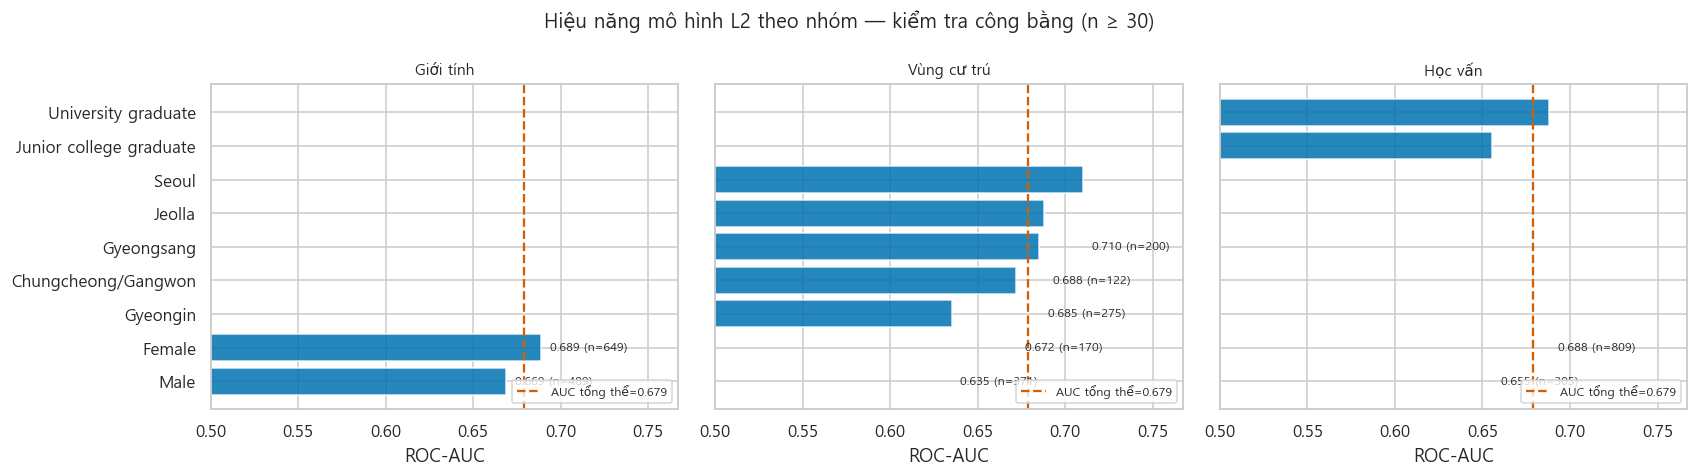

Đọc kết quả: chênh lệch ROC-AUC giữa các nhóm nhỏ ⇒ mô hình tương đối đồng đều;
mọi chênh lệch vẫn là liên hệ trong mẫu pilot, không suy rộng và không nhân quả.


In [33]:
use_inline()
COLNAME = {'gender_label': 'Giới tính', 'region_group_w04_label': 'Vùng cư trú',
           'education_level_w04_label': 'Học vấn'}
groups = list(sg_l2['subgroup_column'].unique())
fig, axes = plt.subplots(1, len(groups), figsize=(5.2 * len(groups), 4.4), sharey=True)
if len(groups) == 1:
    axes = [axes]
overall_auc = results.models['logreg_l2'].test_metrics['roc_auc']
for ax, gcol in zip(axes, groups):
    part = sg_l2[sg_l2['subgroup_column'] == gcol].sort_values('roc_auc')
    ax.barh(part['subgroup_value'].astype(str), part['roc_auc'], color='#0072B2', alpha=0.85)
    ax.axvline(overall_auc, color='#D55E00', ls='--', label=f'AUC tổng thể={overall_auc:.3f}')
    for i, (_, r) in enumerate(part.iterrows()):
        ax.text(r['roc_auc'] + 0.005, i, f"{r['roc_auc']:.3f} (n={int(r['n'])})", va='center', fontsize=8)
    ax.set_title(COLNAME.get(gcol, gcol), fontsize=10)
    ax.set_xlim(0.5, max(0.75, sg_l2['roc_auc'].max() * 1.08))
    ax.set_xlabel('ROC-AUC')
    ax.legend(fontsize=8, loc='lower right')
fig.suptitle('Hiệu năng mô hình L2 theo nhóm — kiểm tra công bằng (n ≥ 30)', fontsize=13)
show()
print('Đọc kết quả: chênh lệch ROC-AUC giữa các nhóm nhỏ ⇒ mô hình tương đối đồng đều;')
print('mọi chênh lệch vẫn là liên hệ trong mẫu pilot, không suy rộng và không nhân quả.')

### 9.6. Hệ số log-odds và đánh đổi bias–variance

Giá trị diễn giải của hồi quy logistic nằm ở **hệ số log-odds**: mỗi hệ số cho biết một
đặc trưng làm tăng hay giảm *log của tỉ lệ cược* có việc. Biểu đồ xếp hạng các đặc trưng
theo độ lớn log-odds của mô hình L2; dấu và độ lớn nhất quán với liên hệ đã thấy ở EDA,
khép kín mạch từ khám phá đến mô hình.


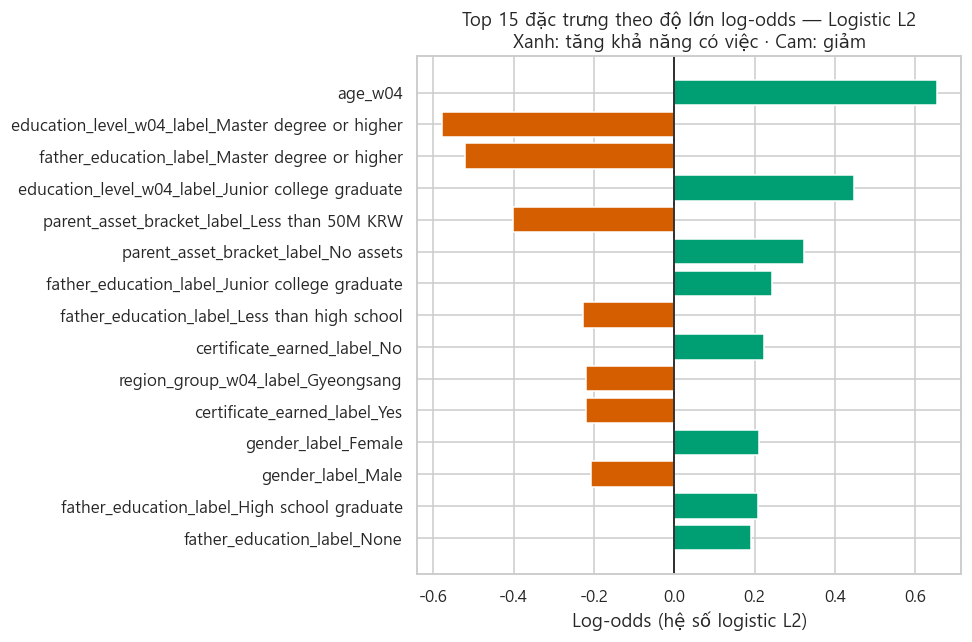

In [34]:
coef = results.coefficients
l2 = coef[(coef['model'] == 'logreg_l2') & (coef['feature'] != '__intercept__')].copy()
top = l2.reindex(l2['log_odds'].abs().sort_values(ascending=False).index).head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#009E73' if v > 0 else '#D55E00' for v in top['log_odds']]
labels = [f.replace('categorical__', '').replace('numeric__', '') for f in top['feature']]
ax.barh(labels, top['log_odds'], color=colors)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Log-odds (hệ số logistic L2)')
ax.set_title('Top 15 đặc trưng theo độ lớn log-odds — Logistic L2\nXanh: tăng khả năng có việc · Cam: giảm')
show()

Về **đánh đổi bias–variance**, ta đọc qua chênh lệch giữa điểm cross-validation
trên tập train và điểm trên tập test. Baseline có bias cao (underfitting) vì quá đơn
giản. Hai mô hình logistic nâng đáng kể chất lượng mà khoảng cách train–CV–test vẫn hẹp —
điều chuẩn L1/L2 kiểm soát tốt phương sai. Random Forest có khoảng cách train–CV lớn hơn
(variance cao hơn) nhưng test ROC-AUC tương đương, cho thấy trần thông tin của tập đặc
trưng (sau khi loại biến leakage) mới là yếu tố giới hạn chính, chứ không phải dạng mô hình.


In [35]:
bv = results.metrics_frame[['model', 'cv_train_roc_auc_mean', 'cv_test_roc_auc_mean',
                            'test_roc_auc', 'cv_test_roc_auc_std']].copy()
bv.columns = ['model', 'CV train AUC', 'CV test AUC', 'Test AUC', 'CV test AUC std']
bv['train - CV gap'] = (bv['CV train AUC'] - bv['CV test AUC']).round(4)
display(bv.round(4))
print('Khoảng cách train→CV hẹp ở logistic ⇒ điều chuẩn kiểm soát phương sai tốt (không overfit).')

,model,CV train AUC,CV test AUC,Test AUC,CV test AUC std,train - CV gap
0,baseline_most_frequent,0.5000,0.5000,0.5000,0.0000,0.0000
1,logreg_l2,0.6943,0.6736,0.6788,0.0242,0.0207
2,logreg_l1,0.6939,0.6741,0.6789,0.0244,0.0198
3,random_forest,0.7378,0.6712,0.6812,0.0248,0.0666


Khoảng cách train→CV hẹp ở logistic ⇒ điều chuẩn kiểm soát phương sai tốt (không overfit).


## 10. Kết luận

Đối chiếu với mục tiêu đặt ra ở phần tóm tắt, báo cáo đã đi trọn vòng đời khoa học dữ
liệu trên YP2021 và trả lời được câu hỏi trọng tâm ở mức *liên hệ/dự đoán*. Trên mẫu
pilot 5.687 người vừa tốt nghiệp, khoảng ba phần tư có việc ở wave 4 (khoảng tin cậy 95%
hẹp, đã kiểm chứng bằng cả urn/binomial lẫn bootstrap), và khả năng có việc liên hệ rõ
nhất với **tuổi**, **chứng chỉ**, **vùng cư trú** cùng **nền tảng học vấn của cha mẹ**.
Mô hình hồi quy logistic có điều chuẩn vượt baseline hằng số một cách ổn định qua
cross-validation, tập kiểm thử và qua hàng trăm lần chia dữ liệu, với khoảng cách
bias–variance hẹp — đủ tin cậy để xếp hạng yếu tố liên hệ, dù sức phân loại tuyệt đối còn
khiêm tốn (ROC-AUC ≈ 0.68) vì tín hiệu trong nhóm đặc trưng nhân khẩu–nền tảng vốn không
mạnh.

Những đóng góp thực tiễn nằm ở chỗ báo cáo không chỉ đưa ra con số mà còn **phơi bày các
ràng buộc** đi kèm: bước lọc học vấn tạo chệch bao phủ, attrition panel tạo chệch không
phản hồi, tiểu mẫu học vấn chi tiết tạo chệch lựa chọn (đã gắn cờ 🟡 trong bảng subgroup),
và ba biến job-history bị loại để chống rò rỉ (đã ghi trong catalog + checklist). Vì thế
mọi kết luận phải đọc trong phạm vi **mẫu pilot wave 4 sau tốt nghiệp**, không suy rộng
cho toàn panel, không diễn giải nhân quả, và không gộp với GOMS hay KEEP II. Những hướng
mở rộng tự nhiên gồm: bổ sung mô hình nhạy cảm có khối học vấn chi tiết sau cờ chỉ báo
khuyết (`--narrow-scope`), hiệu chỉnh trọng số attrition, áp các phép biến đổi đề xuất ở
Mục 6 cho biến lệch, và tách target ba trạng thái (có việc / thất nghiệp / ngoài lực
lượng lao động) thay vì nhị phân.


## 11. Phụ lục — Tái lập (reproducibility checklist)

Toàn bộ artefact của báo cáo tái lập được từ dữ liệu raw bằng chuỗi lệnh dưới đây (chi
tiết và bảng đối chiếu Requirement/Status/Evidence ở `reports/yp2021_reproducibility.md`).

**Pipeline dữ liệu (raw → processed), chạy đúng thứ tự:**

```bash
python -m src.data.youth_panel.pipeline build-metadata
python -m src.data.youth_panel.pipeline build-raw-tables
python -m src.data.youth_panel.pipeline build-panel
python -m src.data.youth_panel.pipeline build-job-history
python -m src.data.youth_panel.pipeline build-construct-candidates
python -m src.data.youth_panel.pipeline build-target-sample
python -m src.data.youth_panel.pipeline build-processed-pilot
```

**Phân tích, mô hình hóa, bất định, EDA sâu, catalog:**

```bash
python -m src.visualization.yp2021_correlation
python -m src.visualization.yp2021_deep_eda
python -m src.models.youth_panel.feature_catalog build
python -m src.models.youth_panel.pipeline build-model
python -m src.models.youth_panel.pipeline build-model --narrow-scope
python -m src.models.youth_panel.sampling_variation run
```

**Notebook & test:**

```bash
python notebooks/_build_yp2021_report_nb.py                 # sinh notebook báo cáo này
jupyter nbconvert --to notebook --execute --inplace notebooks/yp2021_report.ipynb
pytest tests/ -q -k youth_panel
```

**Tính tất định.** Mọi mô hình/mô phỏng seed `RANDOM_STATE = 42`; CSV ghi `utf-8-sig`;
notebook được sinh từ script `notebooks/_build_*.py` rồi execute, nên nguồn versioned và
output tái tạo được. Mọi kết luận là **liên quan/dự đoán, không nhân quả**; chỉ trong
phạm vi pilot wave 4 sau tốt nghiệp, không gộp 3 dataset.
